# Analítica de Crecimiento Basada en Datos: Optimización de Cohortes de Usuarios y del ROI en Marketing para empresa de ticketing
El siguiente proyecto es un análisis para optimizar el ROI de una compañía de venta de boletos, a la vez que se estudia el comportamiento de sus clientes.
Los datasets registran: visitas, pedidos y costos de los gastos de marketing desde junio del 2017 a mayo 2018.

La investigación se divide en dos bloques
1. Análisis de comportamiento:
- cómo los clientes usan el servicio.
- cuándo empiezan a comprar.
- cuánto dinero aporta cada cliente a la compañía. (LTV)
2. Análisis de eficiencia de marketing (CAC, ROMI)
- cuándo los ingresos cubren el costo de adquisición de los clientes.

Se finaliza con recomendaciones



## Primera parte: Limpieza de los datos

Antes de poder análizar los datos, es necesario observarlos, comprender su estructura (tipos de datos, rangos de fechas, duplicados y consistencia entre tablas), limpiarlos y explorarlos.

A continuación se revisan y se hace un diagnóstico de que debe hacerse con ellos.

In [1]:
#Se importan librearias necesarias para el análisis y la presentración de resultados.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import mannwhitneyu

In [2]:
#Se importan las bases de datos
visits_log = pd.read_csv('datasets/visits_log_us.csv') 
orders_log = pd.read_csv('datasets/orders_log_us.csv')
costs_log = pd.read_csv('datasets/costs_us.csv')

#Se revisa su estructura y se observa una muestra del DataFrame
visits_log.info()
print(visits_log.sample(3))
print()
orders_log.info()
print(orders_log.sample(3))
print()
costs_log.info()
print(costs_log.sample(3))

<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  str   
 1   End Ts     359400 non-null  str   
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  str   
 4   Uid        359400 non-null  uint64
dtypes: int64(1), str(3), uint64(1)
memory usage: 13.7 MB
         Device               End Ts  Source Id             Start Ts  \
260391  desktop  2018-02-01 16:47:00          4  2018-02-01 16:35:00   
213399    touch  2017-11-17 23:28:00          2  2017-11-17 23:28:00   
323915  desktop  2017-12-02 23:07:00          3  2017-12-02 23:04:00   

                         Uid  
260391  11897024054955606427  
213399  10795344790962271111  
323915  17357311086076933103  

<class 'pandas.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   

Diagnóstico:
- Se observa que no hay datos nulos en ningun dataset
- Es necesario cambiar el data type de las columnas que incluyen fechas, por ejemplo 'dt' y 'Buy Ts'.
- conviene cambiar a markdown los nombres de columnas con espacios y mayúsculas.  

In [3]:
# Se cambian los nombres de las columnas de visits_log
visits_log.columns = visits_log.columns.str.lower().str.replace(' ', '_')

# Se convierten las columnas de tiempo a datetime en visits_log
visits_log['start_ts'] = pd.to_datetime(visits_log['start_ts'])
visits_log['end_ts'] = pd.to_datetime(visits_log['end_ts'])

# se convierte source_id en categoría en visits_log
visits_log['source_id'] = visits_log['source_id'].astype('category')

# Se cambian los nombres de las columnas de orders_log
orders_log.columns = orders_log.columns.str.lower().str.replace(' ', '_')
# Se convierte la columna de compra en orders_log
orders_log['buy_ts'] = pd.to_datetime(orders_log['buy_ts'])

# Sólo se convierte la columna 'dt' en costs_log
costs_log['dt'] = pd.to_datetime(costs_log['dt'])

# Se comprueba los datos nuevamente
print('información de visits_log')
visits_log.info()
print(visits_log.sample(1))
print(f'Filas con datos nulos en start_ts:{visits_log["start_ts"].isna().sum()}')
print(f'Filas con datos nulos en end_ts:{visits_log["end_ts"].isna().sum()}')
print()
print('información de orders_log')
orders_log.info()
print(orders_log.sample(1))
print(f'Filas con datos nulos en buy_ts:{orders_log["buy_ts"].isna().sum()}')
print()
print('información de costs_log')
costs_log.info()
print(costs_log.sample(1))
print(f'Filas con datos nulos en dt:{costs_log["dt"].isna().sum()}')

información de visits_log
<class 'pandas.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  str           
 1   end_ts     359400 non-null  datetime64[us]
 2   source_id  359400 non-null  category      
 3   start_ts   359400 non-null  datetime64[us]
 4   uid        359400 non-null  uint64        
dtypes: category(1), datetime64[us](2), str(1), uint64(1)
memory usage: 11.3 MB
         device              end_ts source_id            start_ts  \
244481  desktop 2017-08-28 21:54:00         2 2017-08-28 21:54:00   

                         uid  
244481  16434536643231863181  
Filas con datos nulos en start_ts:0
Filas con datos nulos en end_ts:0

información de orders_log
<class 'pandas.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   -----

## Segunda parte: EDA

Una vez verificado los tipos de datos y sabiendo que no hay nulos ni problemas con los Dataframes, se procede a hacer la exploración de los datos para responder las siguientes preguntas:

- ¿Cuántas personas usan el servicio cada día, semana y mes?
- ¿Cuántas sesiones hay por día?
- ¿Cuál es la duración de cada sesión?
- ¿Con qué frecuencia los usuarios regresan?

Para iniciar se usará el DataFrame visits_log para calcular las visitas al sitio web agregadas por día, semana y mes.

In [4]:
# para obtener visitas de usuarios únicos por día
dau = visits_log.groupby(visits_log['start_ts'].dt.date)['uid'].nunique()

# visitas por semana
wau = visits_log.groupby(visits_log['start_ts'].dt.to_period('W'))['uid'].nunique()

# visitas por mes
mau = visits_log.groupby(visits_log['start_ts'].dt.to_period('M'))['uid'].nunique()

# sesiones diarias
daily_sessions = visits_log.groupby(visits_log['start_ts'].dt.date).size()

# se agrega una columna de duración de sesión a visits_log
visits_log['session_duration'] = (visits_log['end_ts'] - visits_log['start_ts']).dt.total_seconds() / 60

Teniendo estas nuevas variables, ahora se crean las siguientes:

- sesiones por usuario
- frecuencia de retorno en días distintos (para no inflar las métricas de retención)
- porcentaje de usuarios que regresan

In [5]:
# sesiones por usuario
sessions_per_user = visits_log.groupby('uid').size()
# se calcula la media
print(f'Media de sesiones por usuario: {sessions_per_user.mean():.2f}')
print()

# Para usuarios que regresan es necesario contar días únicos en los que el usuario tuvo actividad
distinct_days_per_user = visits_log.groupby('uid')['start_ts'].apply(lambda x: x.dt.date.nunique())
# se calcula la media
print(f'Promedio de días con actividad por usuario: {distinct_days_per_user.mean():.2f}')
print()

# Identificar usuarios que regresaron (más de 1 día activo)
returning_users_by_day = distinct_days_per_user[distinct_days_per_user > 1]
total_users = visits_log['uid'].nunique()
print(f'Usuarios que regresan (días distintos): {len(returning_users_by_day)} de {total_users}')
print(f'Porcentaje: {len(returning_users_by_day)/total_users*100:.2f}%')



Media de sesiones por usuario: 1.58

Promedio de días con actividad por usuario: 1.45

Usuarios que regresan (días distintos): 45045 de 228169
Porcentaje: 19.74%


Al analizar el comportamiento de los usuarios, se identifican dos dimensiones diferenciadas: **engagement** (volumen de sesiones) y **retención** (regreso real).

- **Sesiones por usuario:** En promedio, cada usuario genera 1.58 sesiones en todo el período. Sin embargo, esta métrica puede ser engañosa porque no distingue si esas sesiones ocurren en el mismo día o en días distintos.

- **Días activos por usuario:** Para medir la retención de forma más precisa, se calculó el número de días calendario distintos en los que cada usuario tuvo actividad. El promedio cae a 1.45 días.

- **Usuarios que regresan:** Solo el **19.7%** de los usuarios (45,045 de 228,169) tiene actividad en más de un día. Es decir, **4 de cada 5 usuarios visitan la plataforma una única vez** y nunca regresan.

**Avance preliminar:**  
La plataforma no genera hábito ni recurrencia. Esto sugiere que la captación de nuevos usuarios es el principal motor de tráfico, aunque será necesario evaluar el valor de los usuarios recurrentes (LTV) para confirmar su impacto. Esta pista será fundamental para evaluar la eficiencia real de las fuentes de marketing en la segunda parte del análisis.

**Próximas acciones**
- revisar la distribución de los usuarios tanto en sesiones por usuario como en días activos por usuario.
- Explorar las métricas de WAU, MAU, duración de la sesion y las fuentes de atracción.

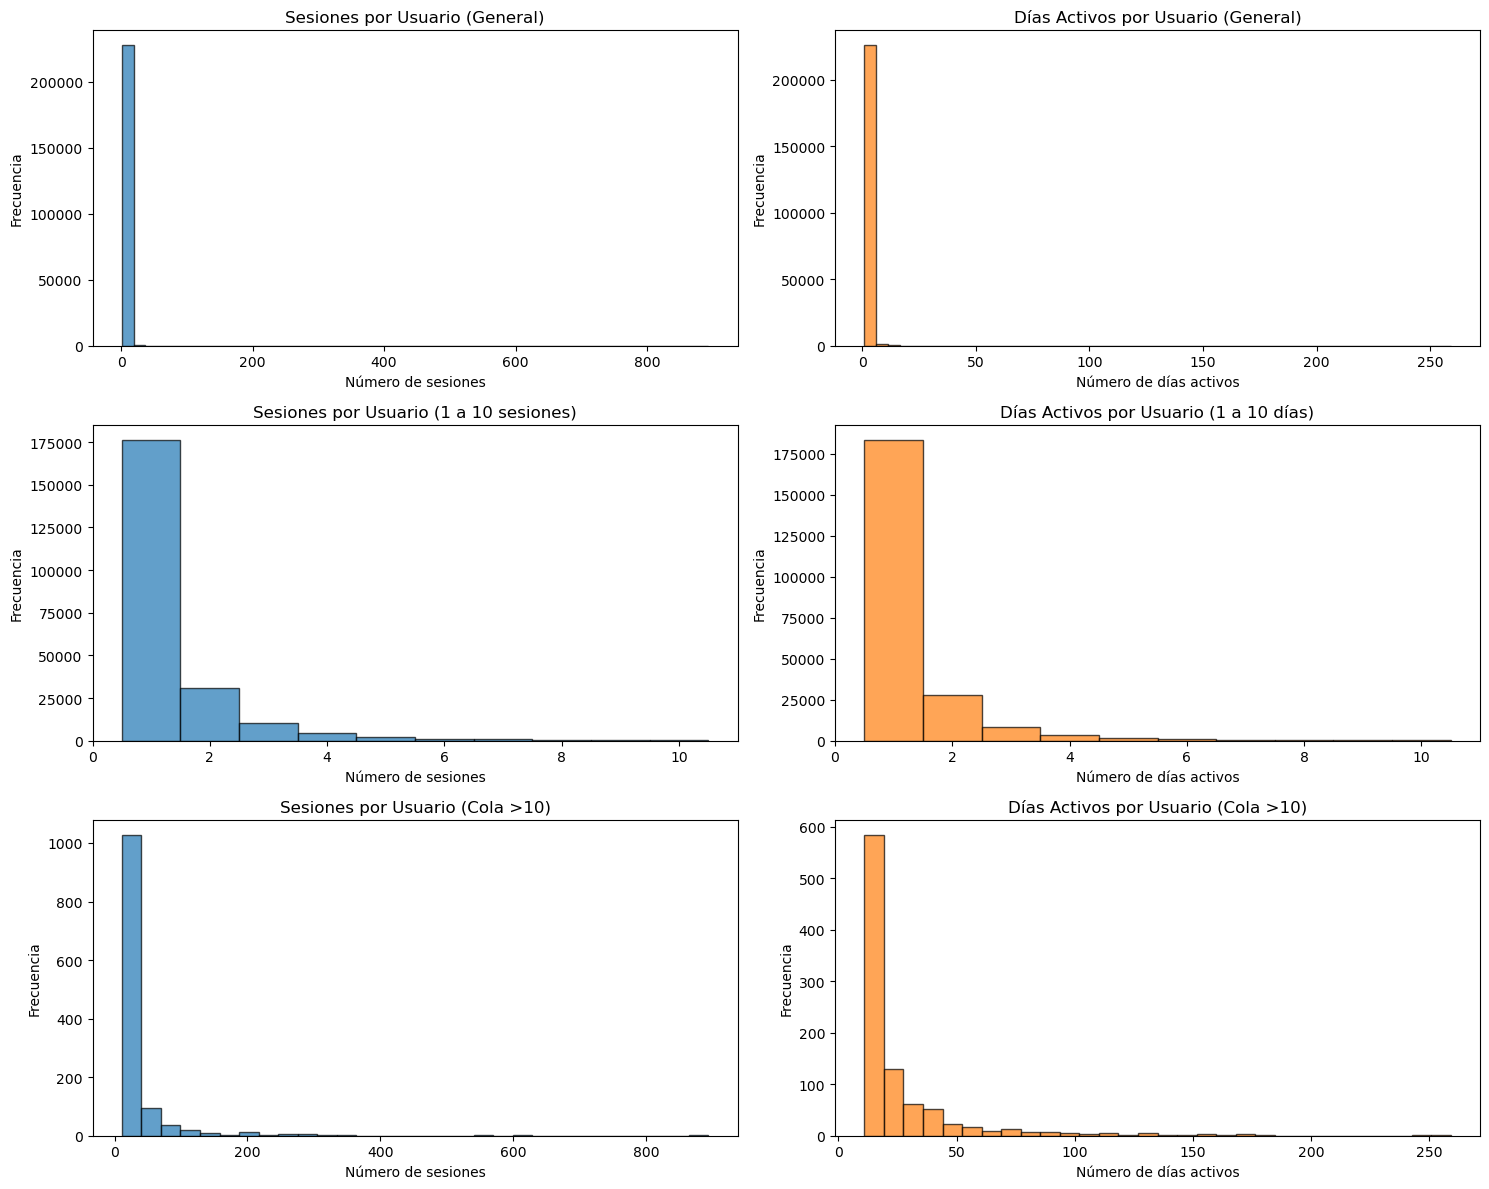

In [6]:
plt.figure(figsize=(15, 12))

# Paleta de colores
color_sessions = '#1f77b4'  
color_days = '#ff7f0e'      

# ---------- FILA 1: General ----------
plt.subplot(3, 2, 1)
plt.hist(sessions_per_user, bins=50, color=color_sessions, edgecolor='black', alpha=0.7)
plt.title('Sesiones por Usuario (General)')
plt.xlabel('Número de sesiones')
plt.ylabel('Frecuencia')

plt.subplot(3, 2, 2)
plt.hist(distinct_days_per_user, bins=50, color=color_days, edgecolor='black', alpha=0.7)
plt.title('Días Activos por Usuario (General)')
plt.xlabel('Número de días activos')
plt.ylabel('Frecuencia')

# ---------- FILA 2: Zoom (1 a 10) ----------
bins_zoom = [0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5, 9.5, 10.5]  # Bordes

plt.subplot(3, 2, 3)
plt.hist(sessions_per_user[sessions_per_user <= 10], bins=bins_zoom, color=color_sessions, edgecolor='black', alpha=0.7)
plt.title('Sesiones por Usuario (1 a 10 sesiones)')
plt.xlabel('Número de sesiones')
plt.ylabel('Frecuencia')

plt.subplot(3, 2, 4)
plt.hist(distinct_days_per_user[distinct_days_per_user <= 10], bins=bins_zoom, color=color_days, edgecolor='black', alpha=0.7)
plt.title('Días Activos por Usuario (1 a 10 días)')
plt.xlabel('Número de días activos')
plt.ylabel('Frecuencia')

# ---------- FILA 3: Cola (>10) ----------
plt.subplot(3, 2, 5)
plt.hist(sessions_per_user[sessions_per_user > 10], bins=30, color=color_sessions, edgecolor='black', alpha=0.7)
plt.title('Sesiones por Usuario (Cola >10)')
plt.xlabel('Número de sesiones')
plt.ylabel('Frecuencia')

plt.subplot(3, 2, 6)
plt.hist(distinct_days_per_user[distinct_days_per_user > 10], bins=30, color=color_days, edgecolor='black', alpha=0.7)
plt.title('Días Activos por Usuario (Cola >10)')
plt.xlabel('Número de días activos')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [7]:
# Estadisticas descriptivas para sesiones por usuario
print("Sesiones por Usuario:")
print(sessions_per_user.describe())
print()

# Estadisticas descriptivas para días activos por usuario
print("Días Activos por Usuario:")
print(distinct_days_per_user.describe())

Sesiones por Usuario:
count    228169.000000
mean          1.575148
std           4.646800
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         893.000000
dtype: float64

Días Activos por Usuario:
count    228169.000000
mean          1.448527
std           2.610167
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max         259.000000
Name: start_ts, dtype: float64


### Resumen de sesiones y días activos

- **Distribución:** Tanto las sesiones por usuario como los días activos por usuario presentan una distribución con un pico masivo en 1 y una cola larga hacia la derecha. El percentil 75 es 1 en ambas variables, lo que indica que al menos el 75% de los usuarios tiene exactamente 1 sesión y exactamente 1 día activo en todo el período.

- **Media engañosa:** La media de sesiones (1.57) y de días activos (1.44) es superior al percentil 75, lo que confirma que estos promedios están inflados por una cola de usuarios extremos (máximo: 893 sesiones y 259 días activos). La mediana (1) es más representativa del usuario típico.

- **Diferencia entre métricas:** La media de sesiones es 0.13 puntos superior a la media de días activos. Esta diferencia, proyectada sobre los 228,169 usuarios, equivale a aproximadamente 8,000 usuarios que generan múltiples sesiones en un único día, pero no regresan al día siguiente.

- **Implicación para el negocio:** Al menos el 75% de los usuarios no regresa después de su primer contacto. La plataforma depende casi exclusivamente de la adquisición de nuevos usuarios. Los 8,000 usuarios "intensivos de un solo día" representan una oportunidad de investigación para entender si su comportamiento está vinculado a compras o a abandono del proceso.

**Próximas acciones:**
- Explorar la evolución temporal de los usuarios únicos a nivel diario, semanal y mensual (DAU, WAU, MAU) para identificar estacionalidad y tendencias.
- Identificar el día con menor número de usuarios (mínimo de DAU) y evaluar si corresponde al inicio o final del período o a una anomalía.
- Generar los gráficos correspondientes de WAU y MAU para complementar el análisis de comportamiento.

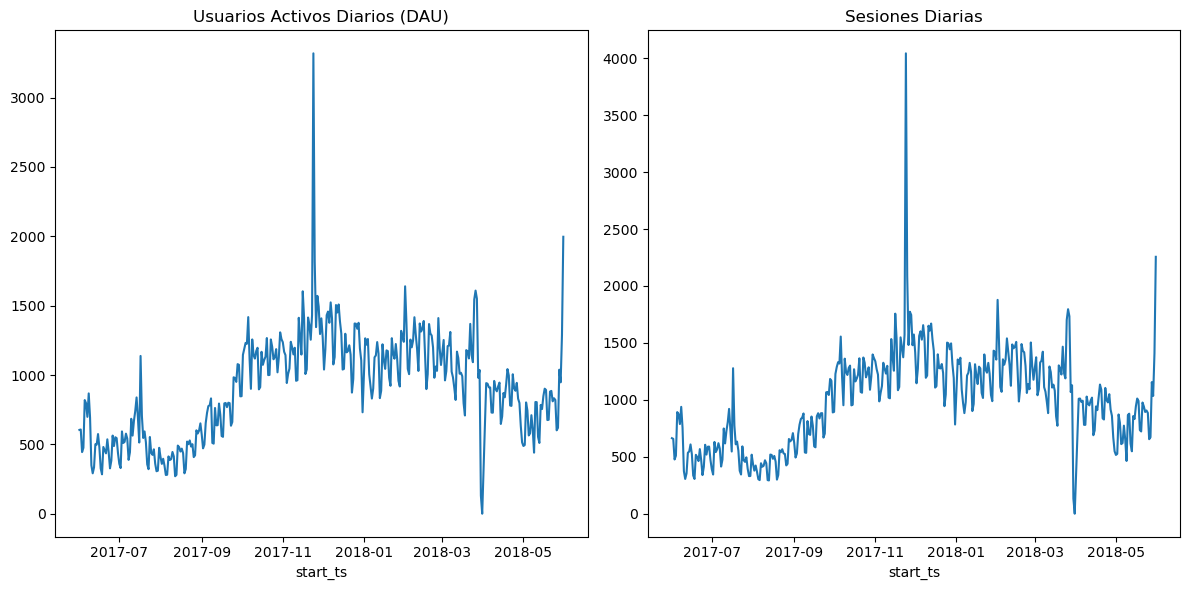

In [8]:
# Gráfico de usuarios activos diarios (DAU) y daily sessions
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
dau.plot(title='Usuarios Activos Diarios (DAU)')
plt.subplot(1, 2, 2)
daily_sessions.plot(title='Sesiones Diarias')
plt.tight_layout()
plt.show()

In [9]:
# Estadísticas del DAU
print('=== Usuarios Activos Diarios (DAU) ===')
print(f'Promedio díario: {dau.mean():.2f} usuarios')
print(f'Máximo diario: {dau.max()} usuarios')
print(f'Mínimo diario: {dau.min()} usuarios')
print()

# Estadísticas del sesiones diarias
print('=== Sesiones Diarias ===')
print(f'Promedio díario: {daily_sessions.mean():.2f} sesiones')
print(f'Máximo diario: {daily_sessions.max()} sesiones')
print(f'Mínimo diario: {daily_sessions.min()} sesiones')
print()

=== Usuarios Activos Diarios (DAU) ===
Promedio díario: 907.99 usuarios
Máximo diario: 3319 usuarios
Mínimo diario: 1 usuarios

=== Sesiones Diarias ===
Promedio díario: 987.36 sesiones
Máximo diario: 4042 sesiones
Mínimo diario: 1 sesiones



### Comportamiento diario: DAU y sesiones

Los gráficos de usuarios activos diarios (DAU) y sesiones diarias muestran una evolución prácticamente idéntica, lo que indica que la relación entre usuarios y sesiones se mantiene estable a lo largo del tiempo. En promedio, cada usuario genera aproximadamente 1.08 sesiones por día, relación que se conserva incluso en los días de mayor tráfico.

**Puntos destacados:**

- **Promedio diario:** 908 usuarios y 987 sesiones.
- **Pico máximo:** 3,319 usuarios y 4,042 sesiones, registrados a finales de noviembre o principios de diciembre. Este pico se identifica como un outlier puntual, ya que los días anteriores y posteriores se mantienen en el rango habitual (900–1,400 usuarios).
- **Valle mínimo:** Se registra un día con solo **1 usuario y 1 sesión** durante el mes de abril. Este valor no llega a cero, por lo que no se trata de una caída total del servicio, sino de un día con actividad prácticamente nula. _La fecha exacta de este día queda pendiente de verificación para determinar si corresponde al inicio/fin del dataset o a una anomalía intermedia._

**Observación:** El comportamiento diario confirma la estacionalidad ya sugerida por las métricas de retención: los picos de tráfico son eventos puntuales (probablemente asociados a campañas o fechas concretas) y no reflejan un cambio estructural en el hábito de los usuarios.

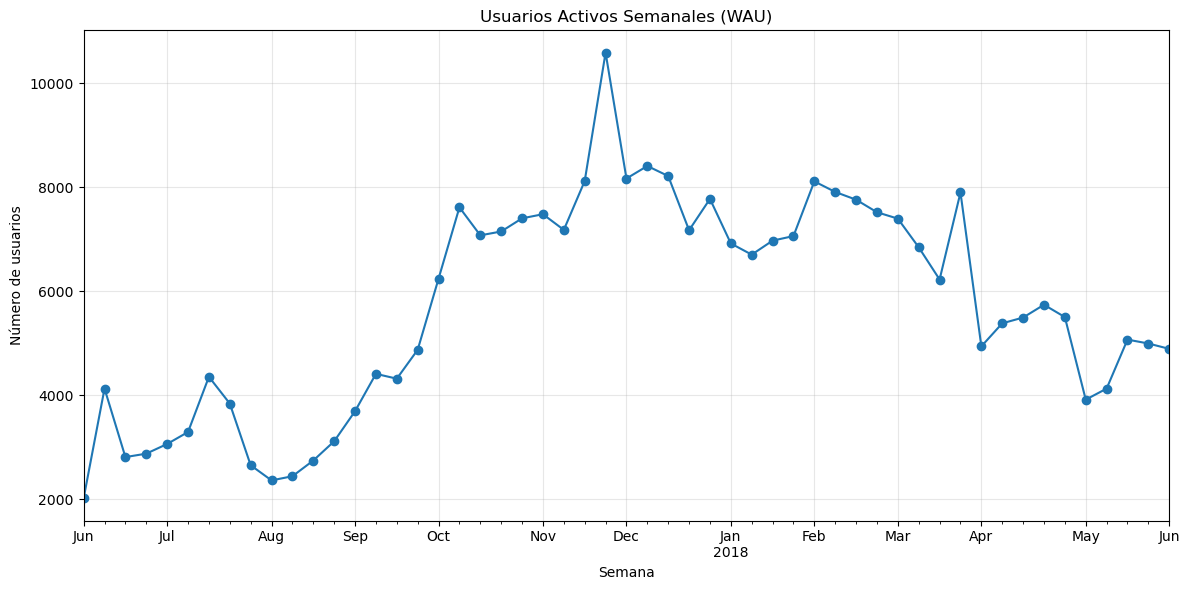

=== Usuarios Activos Semanales (WAU) ===
Promedio semanal: 5716.25 usuarios
Máximo semanal: 10586 usuarios
Mínimo semanal: 2021 usuarios


In [10]:
# Gráfico de sesiones usuarios por semana (WAU)
plt.figure(figsize=(12, 6))
wau.plot(kind='line', marker='o', title='Usuarios Activos Semanales (WAU)')
plt.xlabel('Semana')
plt.ylabel('Número de usuarios')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# estadísticas del WAU
print('=== Usuarios Activos Semanales (WAU) ===')
print(f'Promedio semanal: {wau.mean():.2f} usuarios')
print(f'Máximo semanal: {wau.max()} usuarios')
print(f'Mínimo semanal: {wau.min()} usuarios') 

### Comportamiento semanal: Usuarios Activos Semanales (WAU)

La agregación semanal suaviza la volatilidad diaria y permite identificar tendencias con mayor claridad.

- **Promedio semanal:** 5,716 usuarios.
- **Máximo:** 10,586 usuarios, alcanzado a finales de noviembre.
- **Mínimo:** 2,021 usuarios, registrado en agosto.

**Evolución observada:**

- Desde junio hasta agosto, el WAU se mantiene en niveles bajos (oscilando entre 2,000 y 4,500 usuarios).
- A partir de septiembre, se inicia un ascenso progresivo que culmina en el pico de noviembre.
- Durante diciembre, enero y febrero, el WAU se estabiliza en una meseta alta (entre 6,700 y 8,400 usuarios), sin alcanzar el pico de noviembre.
- Desde marzo en adelante, se observa un descenso gradual que se acentúa en abril y mayo, cerrando el período en torno a los 4,900 usuarios.

**Observación:** La tendencia semanal confirma que el crecimiento de usuarios no es lineal, sino que responde a un patrón estacional con un pico claro en el último trimestre del año y un valle en el periodo de agosto.

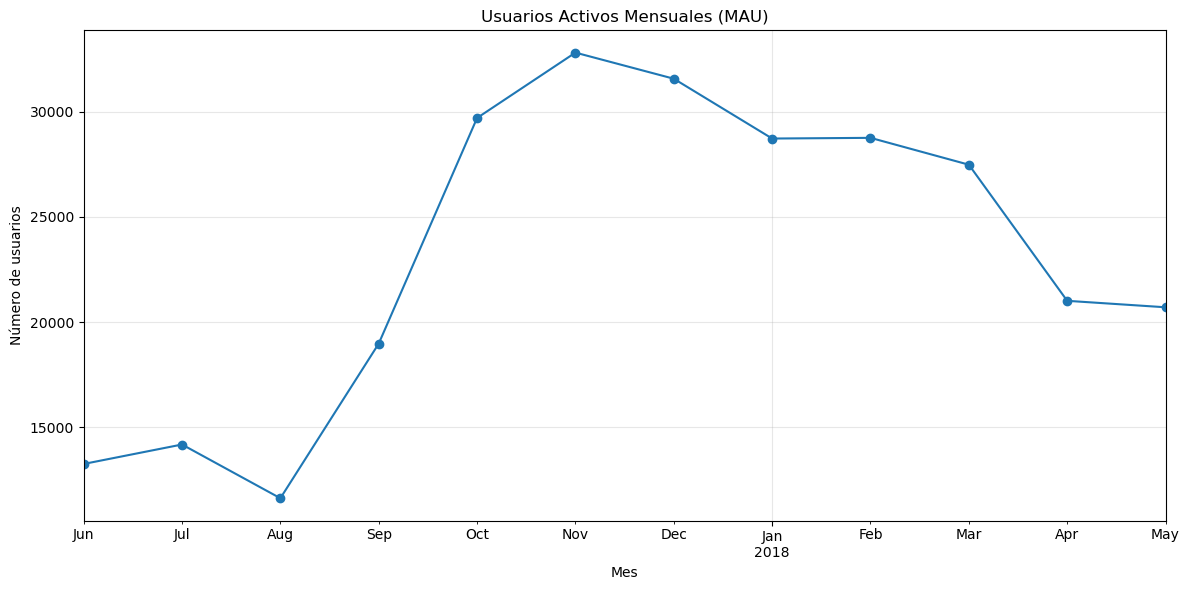

=== Usuarios Activos Mensuales (MAU) ===
Promedio mensual: 23228.42 usuarios
Máximo mensual: 32797 usuarios
Mínimo mensual: 11631 usuarios


In [11]:
# gráfico de usuarios activos por mes (MAU)
plt.figure(figsize=(12, 6))
mau.plot(kind='line', marker='o', title='Usuarios Activos Mensuales (MAU)')
plt.xlabel('Mes')
plt.ylabel('Número de usuarios')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# estadisticas del MAU
print('=== Usuarios Activos Mensuales (MAU) ===')
print(f'Promedio mensual: {mau.mean():.2f} usuarios')
print(f'Máximo mensual: {mau.max()} usuarios')
print(f'Mínimo mensual: {mau.min()} usuarios')


### Comportamiento mensual: Usuarios Activos Mensuales (MAU)

La visión mensual es la más estable y refleja la evolución general del negocio a lo largo del año.

- **Promedio mensual:** 23,228 usuarios.
- **Máximo:** 32,797 usuarios, en noviembre.
- **Mínimo:** 11,631 usuarios, en agosto.

**Evolución observada:**

- Agosto es el mes con menor actividad, con una caída respecto a julio.
- Septiembre muestra un incremento abrupto (de 11,631 a 19,000), iniciando una escalada que continúa en octubre (29,600) y alcanza su punto máximo en noviembre (32,797).
- Diciembre se mantiene en niveles altos (31,600), y enero-febrero se estabilizan en torno a los 28,700 usuarios.
- Marzo inicia un descenso moderado (27,500), que se acentúa en abril (21,000) y se estabiliza en mayo (20,700).

**Observación:** La evolución mensual refuerza el patrón estacional detectado en el WAU: un trimestre final del año con alta afluencia, un invierno (enero-marzo) con una base de usuarios estable y una primavera (abril-mayo) con una caída progresiva. Este patrón será relevante al evaluar la eficiencia de las campañas de marketing, ya que sugiere que la adquisición de usuarios no es uniforme a lo largo del año.

### Próximos pasos dentro del EDA

Antes de pasar al análisis de cohortes (donde se cruzará el comportamiento con los pedidos y se calculará el LTV), es necesario completar la exploración de las métricas de comportamiento pendientes. Estas permitirán tener un panorama completo del usuario antes de evaluar su valor económico.

A continuación, se describen las tres exploraciones que restan dentro de esta fase:

#### 1. Duración de sesión
Se analizará la distribución de `session_duration` (en minutos) para comprender cuánto tiempo permanecen los usuarios en la plataforma. 

#### 2. Distribución de usuarios por fuente (`source_id`)
Se explorará la procedencia de los usuarios según el identificador de la fuente de anuncios (`source_id`).

#### 3. Relación entre duración de sesión y dispositivo
Se evaluará si el tipo de dispositivo (`device`) está asociado a diferencias en la duración de la sesión. 

In [12]:
# Se crea una columna de duración de sesión en minutos
visits_log['session_duration'] = (visits_log['end_ts'] - visits_log['start_ts']).dt.total_seconds() / 60

# estadísticas de duración de sesión
print('=== Duración de Sesión (minutos) ===')
print(visits_log['session_duration'].describe())

=== Duración de Sesión (minutos) ===
count    359400.000000
mean         10.717095
std          16.618796
min         -46.000000
25%           2.000000
50%           5.000000
75%          14.000000
max         711.000000
Name: session_duration, dtype: float64


El valor mínimo señála que hay un problema pues no puede haber valores negativos de tiempo. se investiga cuantos valores hay así para trabajar sobre ellos.

In [13]:
# se verifica cuantos valores de tiempo negativos hay en el dataframe
print(f'Filas con duración de sesión negativa: {visits_log[visits_log['session_duration'] < 0].shape[0]}')

# se muestra los percentiles 99 y 95 de duración de sesión
print(f'Percentil 99 de duración de sesión: {visits_log['session_duration'].quantile(0.99):.2f} minutos')
print(f'Percentil 95 de duración de sesión: {visits_log['session_duration'].quantile(0.95):.2f} minutos')

Filas con duración de sesión negativa: 2
Percentil 99 de duración de sesión: 75.00 minutos
Percentil 95 de duración de sesión: 38.00 minutos


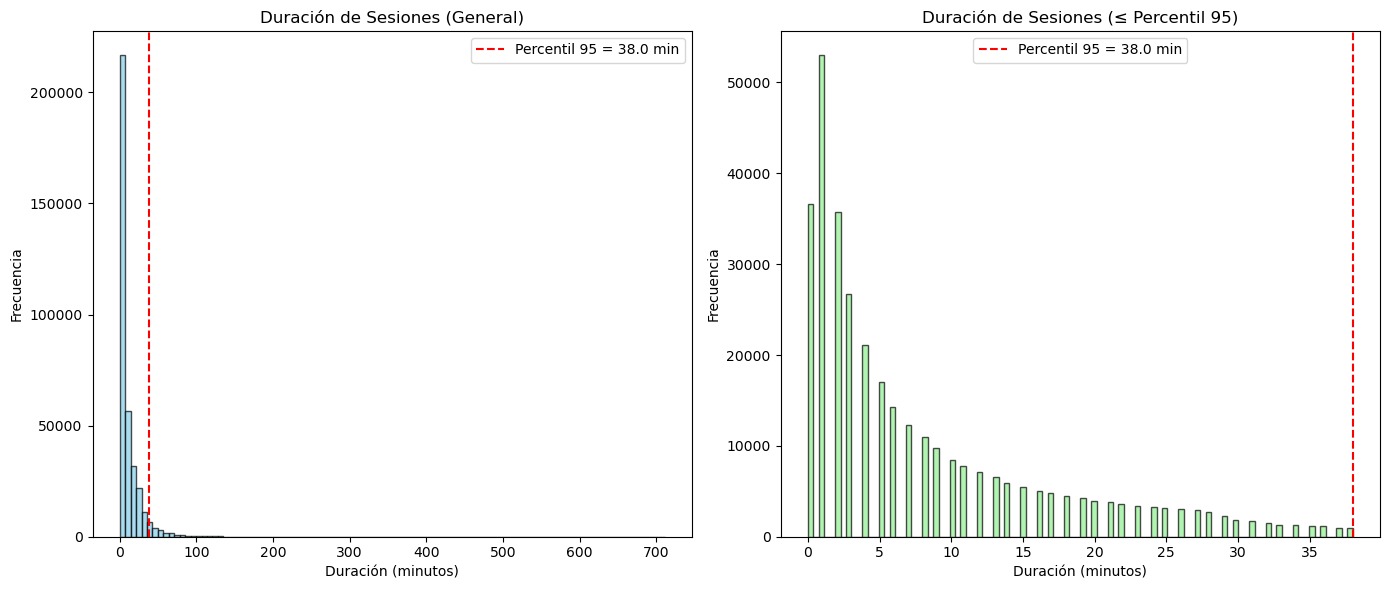

In [14]:
# se eliminan los valores negativos de duración de sesión
visits_log_pos = visits_log[visits_log['session_duration'] >= 0].copy()


# Crear la figura con dos subplots
plt.figure(figsize=(14, 6))
# se define umbral para el percentil 95
umbral = visits_log_pos['session_duration'].quantile(0.95)

# Histograma general (todos los datos)
plt.subplot(1, 2, 1)
plt.hist(visits_log_pos['session_duration'], bins=100, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Duración de Sesiones (General)')
plt.xlabel('Duración (minutos)')
plt.ylabel('Frecuencia')
plt.axvline(x=umbral, color='red', linestyle='--', label=f'Percentil 95 = {umbral:.1f} min')
plt.legend()

# Histograma filtrado (sesiones <= percentil 95)
plt.subplot(1, 2, 2)
datos_filtrados = visits_log_pos[visits_log_pos['session_duration'] <= umbral]['session_duration']
plt.hist(datos_filtrados, bins=100, color='lightgreen', edgecolor='black', alpha=0.7)
plt.title('Duración de Sesiones (≤ Percentil 95)')
plt.xlabel('Duración (minutos)')
plt.ylabel('Frecuencia')
plt.axvline(x=umbral, color='red', linestyle='--', label=f'Percentil 95 = {umbral:.1f} min')
plt.legend()

plt.tight_layout()
plt.show()

### Duración de sesión: el comportamiento típico es breve

La exploración de la duración de las sesiones arroja un hallazgo coherente con el perfil de plataforma de transacción rápida: la mayoría de las sesiones se concentra en los primeros minutos.

- **Distribución general:** la duración media (10.7 min) está inflada por una cola de sesiones largas. La mediana (5 min) y el percentil 75 (14 min) muestran que la mitad de las sesiones duran 5 minutos o menos.
- **Valores atípicos:** se detectaron 2 sesiones con duración negativa, que fueron eliminadas por tratarse de errores de registro. El percentil 95 se sitúa en 38 minutos, por lo que el 95% de las sesiones no supera este tiempo.
- **Concentración en el inicio:** el histograma filtrado (≤ 38 min) revela un pico en los primeros minutos (0 a 2 min), con una caída exponencial a partir del minuto 5. Las sesiones largas (> 15 min) son escasas.

**¿Qué implica esto para el negocio?**  
La plataforma no fomenta la navegación prolongada. Los usuarios entran, resuelven su necesidad (probablemente comprar o consultar) y salen. Esto refuerza la idea de que la conversión es rápida o no ocurre. La pregunta de si los usuarios que compran tienen una duración mínima de sesión se responderá al cruzar estos datos con `orders_log_pos` en el análisis de cohortes.

**Próximos pasos en el EDA:**  
Se explorará la procedencia de los usuarios (`source_id`) y la relación entre duración y dispositivo (`device`) para completar el perfil de comportamiento antes de pasar al análisis de ingresos.

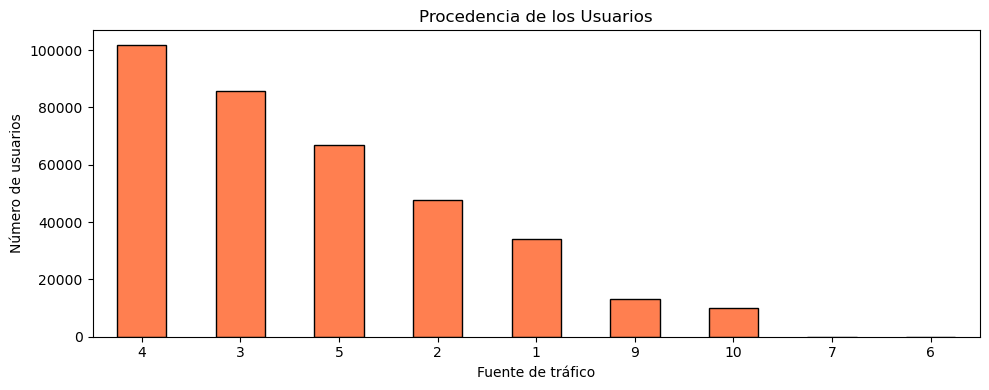

           usuarios  porcentaje
source_id                      
4            101794       28.32
3             85609       23.82
5             66905       18.62
2             47626       13.25
1             34121        9.49
9             13276        3.69
10            10025        2.79
7                36        0.01
6                 6        0.00


In [15]:
# Gráfico de la procedencia de los usuarios
plt.figure(figsize=(10, 4))
visits_log_pos['source_id'].value_counts().plot(kind='bar', color='coral', edgecolor='black')
plt.title('Procedencia de los Usuarios')
plt.xlabel('Fuente de tráfico')
plt.ylabel('Número de usuarios')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Resumen de la procedencia de los usuarios
source_counts = visits_log_pos['source_id'].value_counts()
source_percent = visits_log_pos['source_id'].value_counts(normalize=True) * 100
source_summary = pd.DataFrame({
    'usuarios': source_counts,
    'porcentaje': source_percent
})
print(source_summary.round(2))

### Procedencia de los usuarios

La distribución de usuarios por fuente de tráfico muestra una concentración clara en unos pocos canales.

- **Fuentes principales:** Las fuentes 3, 4 y 5 concentran la mayor parte del tráfico. La fuente 4 es la que aporta el mayor volumen de usuarios, seguida de cerca por la fuente 3 y, en tercer lugar, la fuente 5.
- **Fuentes marginales:** Las fuentes 6 y 7 tienen un volumen de usuarios prácticamente nulo en el período analizado.
- **Desequilibrio:** El tráfico no está distribuido de forma homogénea entre los canales. Esta desigualdad será relevante al evaluar la eficiencia de cada fuente en el bloque de marketing, donde se incorporarán los costos y se calculará el retorno de inversión (ROMI).

=== Estadísticas de duración por dispositivo ===
            count       mean        std  min  25%  50%   75%    max
device                                                             
desktop  262565.0  11.721867  17.783834  0.0  2.0  6.0  15.0  711.0
touch     96833.0   7.993657  12.542192  0.0  1.0  3.0  10.0  514.0

=== Percentiles por dispositivo ===
         0.95
device       
desktop  42.0
touch    29.0


<Figure size 1000x600 with 0 Axes>

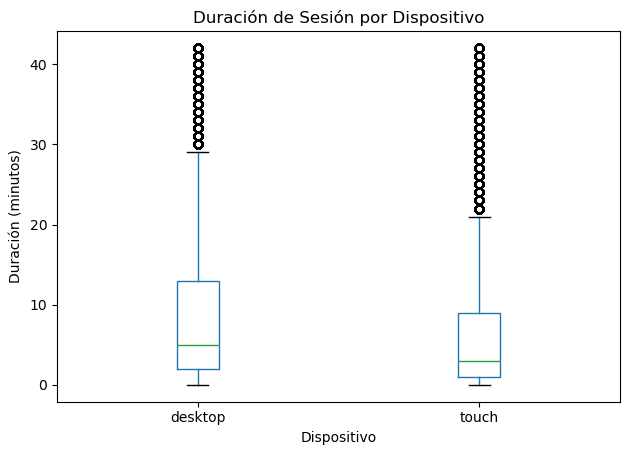

In [16]:
# Estadísticas de duración por dispositivo
print("=== Estadísticas de duración por dispositivo ===")
print(visits_log_pos.groupby('device')['session_duration'].describe())
print("\n=== Percentiles por dispositivo ===")
print(visits_log_pos.groupby('device')['session_duration'].quantile([0.95]).unstack())

# Boxplot de duración de sesión por dispositivo
plt.figure(figsize=(10, 6))
visits_log_pos[visits_log_pos['session_duration'] <= 42].boxplot(column='session_duration', by='device', grid=False) # se limita a sesiones de hasta 42 minutos para mejor visualización
plt.title('Duración de Sesión por Dispositivo')
plt.suptitle('')  # Elimina el título automático de pandas
plt.xlabel('Dispositivo')
plt.ylabel('Duración (minutos)')
 # Escala logarítmica para comprimir la cola
plt.tight_layout()
plt.show()

### Duración de sesión por dispositivo

- **Diferencia en mediana:** Los usuarios de escritorio tienen una mediana de 6 minutos, frente a 3 minutos en móvil. La misma diferencia se mantiene en el percentil 95 (42 min vs 29 min). Esto indica que la diferencia en duración no es un efecto de cola, sino un patrón que se mantiene en toda la distribución.

- **Distribuciones:** Ambos dispositivos presentan distribuciones sesgadas a la derecha, con una alta concentración de sesiones en los primeros minutos. La cola de sesiones largas es más pronunciada en desktop que en móvil.

- **Preguntas abiertas:** El patrón observado plantea preguntas para el siguiente bloque del análisis:
  - ¿La mayor duración en desktop está asociada a una mayor propensión a comprar?
  - ¿Los usuarios de móvil, al tener sesiones más cortas, completan compras más rápidas o abandonan con mayor frecuencia?
  - ¿La diferencia en duración se traduce en diferencias en el ticket promedio o en el LTV?

Estas preguntas se abordarán en el análisis de cohortes, donde se cruzará la información de duración y dispositivo con los pedidos.

## Tercera parte: Análisis de cohortes.

El análisis exploratorio ha dejado abiertas varias cuestiones: La retención es baja, hay un grupo de usuarios con múltiples sesiones en un mismo día y los picos de tráfico no tienen, aún, explicación. Para responder si estos patrones se traducen en ingresos, es necesario cruzar el comportamiento de los usuarios con sus pedidos reales.

A continuación se crea el perfil económico por usuario y, a partir de él, se responderan las preguntas pendientes y definirá cohortes de conversión que permitan evaluar el valor de cada grupo de clientes.

Para ello, se seguirán cuatro pasos:

1. **Construcción de variables:** unir los datos de visitas con los de pedidos para obtener, por usuario, indicadores de compra (si compró, cuándo fue su primera compra, cuántos pedidos realizó y el ingreso total generado).

2. **Investigación de las pistas del EDA:** una vez creado el perfil de usuario, se explorarán los casos específicos identificados en la fase anterior, como el día con un solo usuario, la composición del pico de noviembre, la relación entre duración de sesión y compra, y el comportamiento de los usuarios con sesiones múltiples en un mismo día.

3. **Cohortes de conversión por tiempo:** se replicará el análisis clásico de cohortes basado en el tiempo transcurrido entre la primera visita y la primera compra, clasificando a los usuarios en grupos  para calcular su ticket promedio, pedidos por usuario y LTV.

4. **Segmentación cruzada:** las cohortes de conversión se cruzarán con variables de comportamiento (dispositivo y fuente de tráfico) para identificar si el valor de cada cohorte varía según el perfil de usuario.

Este recorrido permitirá cerrar las preguntas abiertas del EDA y, al mismo tiempo, construir una base sólida para el análisis de marketing que vendrá después.

In [17]:
# Para preparar los datos y unir los DataFrames visits_log_pos y orders_log, se crea un DF de agregación.
visits_agg = visits_log_pos.groupby('uid').agg(
    first_visit = ('start_ts', 'min'),
    total_sessions = ('session_duration', 'count'),
    total_days_active = ('start_ts', lambda x: x.dt.date.nunique()),
    avg_session_duration = ('session_duration', 'mean'),
    primary_device = ('device', lambda x: x.mode()[0] if not x.mode().empty else None)
).reset_index()

# Para agregar first_touch se usa idxmin
first_touch = visits_log_pos.loc[visits_log_pos.groupby('uid')['start_ts'].idxmin(), ['uid', 'source_id']]

# prueba de la estructura de los dfs
visits_agg.info()
print(visits_agg.head())
print()
first_touch.info()
print(first_touch.head())


<class 'pandas.DataFrame'>
RangeIndex: 228169 entries, 0 to 228168
Data columns (total 6 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   uid                   228169 non-null  uint64        
 1   first_visit           228169 non-null  datetime64[us]
 2   total_sessions        228169 non-null  int64         
 3   total_days_active     228169 non-null  int64         
 4   avg_session_duration  228169 non-null  float64       
 5   primary_device        228169 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(2), str(1), uint64(1)
memory usage: 10.4 MB
               uid         first_visit  total_sessions  total_days_active  \
0   11863502262781 2018-03-01 17:27:00               1                  1   
1   49537067089222 2018-02-06 15:55:00               1                  1   
2  297729379853735 2017-06-07 18:47:00               1                  1   
3  313578113262317 2017-09-18 22

In [18]:
# Ahora se crea un DataFrame de órdenes agregadas por usuario
orders_agg = orders_log.groupby('uid').agg(
    first_order = ('buy_ts', 'min'),
    total_orders = ('buy_ts', 'count'),
    total_revenue = ('revenue', 'sum')
).reset_index()

# se comprueba la estructura del DataFrame orders_agg
orders_agg.info()
print(orders_agg.head())

<class 'pandas.DataFrame'>
RangeIndex: 36523 entries, 0 to 36522
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   uid            36523 non-null  uint64        
 1   first_order    36523 non-null  datetime64[us]
 2   total_orders   36523 non-null  int64         
 3   total_revenue  36523 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), uint64(1)
memory usage: 1.1 MB
                uid         first_order  total_orders  total_revenue
0   313578113262317 2018-01-03 21:51:00             1           0.55
1  1575281904278712 2017-06-03 10:13:00             2           3.05
2  2429014661409475 2017-10-11 18:33:00             1          73.33
3  2464366381792757 2018-01-28 15:54:00             1           2.44
4  2551852515556206 2017-11-24 10:14:00             2          10.99


In [19]:
#Ahora se hace el merge de los DataFrames, primero visits_agg con first_touch y luego con orders_agg para mejor rastreabilidad.
user_profile_visits = pd.merge(visits_agg, first_touch, on='uid', how= 'left')

# se usa left join para mantener todos los usuarios que han visitado el sitio, incluso si no han realizado compras.
user_profile = pd.merge(user_profile_visits, orders_agg, on='uid', how='left')

# se comprueba la estructura del DataFrame user_profile
print('=== Información del DataFrame user_profile ===')
user_profile.info()
print(user_profile.head())

=== Información del DataFrame user_profile ===
<class 'pandas.DataFrame'>
RangeIndex: 228169 entries, 0 to 228168
Data columns (total 10 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   uid                   228169 non-null  uint64        
 1   first_visit           228169 non-null  datetime64[us]
 2   total_sessions        228169 non-null  int64         
 3   total_days_active     228169 non-null  int64         
 4   avg_session_duration  228169 non-null  float64       
 5   primary_device        228169 non-null  str           
 6   source_id             228169 non-null  category      
 7   first_order           36523 non-null   datetime64[us]
 8   total_orders          36523 non-null   float64       
 9   total_revenue         36523 non-null   float64       
dtypes: category(1), datetime64[us](2), float64(3), int64(2), str(1), uint64(1)
memory usage: 15.9 MB
               uid         first_visit  tot

In [20]:
# se renombra source_id a first_touch_source para mayor claridad
user_profile.rename(columns={'source_id': 'first_touch_source'}, inplace=True)

# se agregan las siguientes columnas: buyer (si el usuario ha comprado o no), days_to_first_order.
user_profile['buyer'] = user_profile['total_revenue'].notna()

user_profile['days_to_first_order'] = (user_profile['first_order'] - user_profile['first_visit']).dt.days

# prueba de la estructura del DataFrame user_profile
print(user_profile.sample(5))

                         uid         first_visit  total_sessions  \
217016  17536252082182740209 2017-12-16 17:32:00               1   
122252   9884079371408406177 2017-12-09 19:11:00               1   
31052    2517264213878334922 2018-01-26 12:51:00               1   
73370    5917704072635562549 2018-03-06 16:01:00               1   
193826  15664559398221069064 2018-04-17 18:11:00               1   

        total_days_active  avg_session_duration primary_device  \
217016                  1                  11.0        desktop   
122252                  1                   1.0        desktop   
31052                   1                   2.0        desktop   
73370                   1                  34.0        desktop   
193826                  1                  12.0        desktop   

       first_touch_source         first_order  total_orders  total_revenue  \
217016                  3                 NaT           NaN            NaN   
122252                  3             

## Construcción del perfil de usuario

Se ha creado el DataFrame `user_profile`, que consolida a nivel de usuario la información de comportamiento (visitas) y de ingresos (pedidos). Este perfil permite relacionar las métricas de uso con la actividad de compra.

**Columnas principales:**

- **Comportamiento:** 
    - primera visita (`first_visit`) 
    - total de sesiones (`total_sessions`)
    - días activos (`total_days_active`)
    - duración promedio de sesión (`avg_session_duration`)
    - dispositivo principal (`primary_device`) 
    - fuente de primera visita (`first_touch_source`).
- **Compra:** 
    - fecha de la primera orden (`first_order`)
    - número de pedidos (`total_orders`)
    - ingreso total (`total_revenue`).
- **Derivadas:** 
    - indicador de compra (`buyer`)
    - días hasta la primera orden (`days_to_first_order`).

**Siguientes pasos:**
Con este perfil se dispone de la estructura necesaria para abordar las investigaciones pendientes identificadas en el EDA:
la fecha del día con un solo usuario, la composición del pico de noviembre, el comportamiento de los usuarios con múltiples sesiones en un mismo día y la relación entre la duración de la sesión y la conversión a compra.

In [21]:
# Se comprueban los bordes del dataset original
print(f'Primer día registrado: {visits_log["start_ts"].min().date()}')
print(f'Último día registrado: {visits_log["start_ts"].max().date()}')
print()

# Se comienza con indagación la fecha de un sólo usuario
print('día con menor actividad (DAU mínimo):')
print(dau.idxmin())

Primer día registrado: 2017-06-01
Último día registrado: 2018-05-31

día con menor actividad (DAU mínimo):
2018-03-31


Considerando que la fecha con el menor tráfico no está en los bordes del data set se busca el usuario y el comportamiento de ese día.

In [22]:
# Se pesca el uid del usuario que entró en el día con menor actividad
anomalous_day_user = visits_log[visits_log['start_ts'].dt.date == dau.idxmin()]['uid'].unique()
print(f'Usuarios que entraron en el día con menor actividad: {anomalous_day_user}')

#se obtiene el overview del usuario que entró en el día con menor actividad
print(user_profile[user_profile['uid'].isin(anomalous_day_user)])

Usuarios que entraron en el día con menor actividad: [7789160382257434989]
                       uid         first_visit  total_sessions  \
96504  7789160382257434989 2018-03-31 14:24:00               1   

       total_days_active  avg_session_duration primary_device  \
96504                  1                   1.0        desktop   

      first_touch_source first_order  total_orders  total_revenue  buyer  \
96504                  1         NaT           NaN            NaN  False   

       days_to_first_order  
96504                  NaN  


### Investigación 1: día de un sólo usuario.

**Resultado:** El día con un solo usuario (2018-03-31) corresponde a un usuario de escritorio, fuente 1, que no realizó compras. No se encuentra en los bordes del período y se descarta como una anomalía sin impacto en las conclusiones.

**Próximo paso:** Se analiza el pico de venta más alto: noviembre.

In [23]:
# Se obtiene el día de más actividad (DAU máximo)
print('día con mayor actividad (DAU máximo):')
peek_visits_day = dau.idxmax()
print(peek_visits_day)

# se crean variables para el día anterior y posterior al día de mayor actividad para análisis posterior
post_day = peek_visits_day + pd.Timedelta(days=1)
pre_day = peek_visits_day - pd.Timedelta(days=1)

peek_visits_days = [pre_day, peek_visits_day, post_day]

# Se filtra el DataFrame visits_log para obtener sólo los registros de los días de mayor actividad y sus días adyacentes
filtered_visits_log = visits_log[visits_log['start_ts'].dt.date.isin(peek_visits_days)]

uids_peek_visits = filtered_visits_log['uid'].unique()

peek_days_profiles = user_profile[user_profile['uid'].isin(uids_peek_visits)]

#estadisticas descriptivas de las métricas clave:)
print(peek_days_profiles[['total_days_active', 'avg_session_duration']].describe())
print()

print('Fuentes de tráfico de los usuarios que visitaron en el día de mayor actividad y sus días adyacentes:')
print(peek_days_profiles['first_touch_source'].value_counts())
print()

print('Porcentaje de compradores entre los usuarios que visitaron en el día de mayor actividad y sus días adyacentes:')
buyer_ratio = peek_days_profiles['buyer'].mean()
print(f'{buyer_ratio:.2%}')

día con mayor actividad (DAU máximo):
2017-11-24
       total_days_active  avg_session_duration
count        6086.000000           6086.000000
mean            3.952350             12.057825
std            12.574042             14.633390
min             1.000000              0.000000
25%             1.000000              3.000000
50%             1.000000              7.817361
75%             3.000000             16.142857
max           259.000000            244.000000

Fuentes de tráfico de los usuarios que visitaron en el día de mayor actividad y sus días adyacentes:
first_touch_source
3     1949
4     1469
5     1007
2      657
9      467
1      382
10     155
6        0
7        0
Name: count, dtype: int64

Porcentaje de compradores entre los usuarios que visitaron en el día de mayor actividad y sus días adyacentes:
27.79%


In [24]:
# Se muestra en ratio global de compradores para comparar con el ratio de los días de mayor actividad.
print('Ratio global de compradores:')
print(f'{user_profile["buyer"].mean():.2%}')

# Ratio de compra de los usuarios nuevos (anual)
new_buyers_annual = user_profile[(user_profile['total_days_active'] == 1) & (user_profile['buyer'] == True)]
print(f"Número de usuarios que compran en su primera visita (anual): {len(new_buyers_annual)}")
print(f"Ratio de compra de usuarios que compran en su primera visita (anual): {len(new_buyers_annual)/len(user_profile[user_profile['total_days_active'] == 1]):.2%}")

# Ratio de compra de los usuarios que regresan (anual)
returning_buyers_annual = user_profile[(user_profile['total_days_active'] > 1) & (user_profile['buyer'] == True)]
print(f"Número de usuarios que regresaron y compraron (anual): {len(returning_buyers_annual)}")
print(f"Ratio de compra de los usuarios que regresaron (anual): {len(returning_buyers_annual)/len(user_profile[user_profile['total_days_active'] > 1]):.2%}")
print()
print('=== Análisis de los días de mayor actividad ===')
#Ratio de compra de los usuarios nuevos en los días de mayor actividad
first_time_buyers = peek_days_profiles[(peek_days_profiles['total_days_active'] == 1) & (peek_days_profiles['buyer'] == True)]
print(f"Número de usuarios nuevos que compranron en los días de mayor actividad: {len(first_time_buyers)}")
print(f"Ratio de compra de los usuarios nuevos en los días de mayor actividad: {len(first_time_buyers)/len(peek_days_profiles[peek_days_profiles['total_days_active'] == 1]):.2%}")

#ratio de compra de los usuarios que regresaron en los días de mayor actividad
users_returning = peek_days_profiles[(peek_days_profiles['total_days_active'] > 1) & (peek_days_profiles['buyer'] == True)]
print(f"Número de usuarios que regresaron y compraron en los días de mayor actividad: {len(users_returning)}")
print(f"Ratio de compra de los usuarios que regresaron en los días de mayor actividad: {len(users_returning)/len(peek_days_profiles[peek_days_profiles['total_days_active'] > 1]):.2%}")

Ratio global de compradores:
16.01%
Número de usuarios que compran en su primera visita (anual): 21312
Ratio de compra de usuarios que compran en su primera visita (anual): 11.64%
Número de usuarios que regresaron y compraron (anual): 15211
Ratio de compra de los usuarios que regresaron (anual): 33.77%

=== Análisis de los días de mayor actividad ===
Número de usuarios nuevos que compranron en los días de mayor actividad: 434
Ratio de compra de los usuarios nuevos en los días de mayor actividad: 13.22%
Número de usuarios que regresaron y compraron en los días de mayor actividad: 1257
Ratio de compra de los usuarios que regresaron en los días de mayor actividad: 44.86%


### Hallazgos preliminares del pico de tráfico (Black Friday)

El día de mayor actividad corresponde al **24 de noviembre de 2017** (Black Friday), con 3,319 usuarios únicos . Para capturar el efecto completo del fin de semana de compras, se analizó una ventana de ±1 día (23-25 de noviembre), que concentró **6,086 usuarios únicos**.

#### Composición del pico
- **Fuente principal:** La fuente 3 fue el principal impulsor del tráfico (1,949 usuarios, 32% del total), seguida de las fuentes 4 (1,469) y 5 (1,007).
- **Perfil de usuarios:** La mediana de `total_days_active` es 1, y el 75% de los usuarios tiene 3 o menos días activos. Esto indica que la mayoría de los visitantes del pico eran usuarios nuevos o con muy poca actividad previa.

#### Rendimiento del pico
- **Tasa de compra global del pico:** 27.79% (frente al 16.01% anual). El pico atrajo a usuarios con mayor propensión a comprar que el promedio del año.

- **Segmentación por tipo de usuario:**
  - **Usuarios nuevos (total_days_active == 1):** 3,282 usuarios (54% del pico). Su tasa de compra fue del 13.22%, ligeramente superior al 11.64% que registran los nuevos usuarios en el resto del año.
  - **Usuarios recurrentes (total_days_active > 1):** 2,804 usuarios (46% del pico). Su tasa de compra fue del 44.86%, muy por encima del 33.77% que registran los recurrentes en el resto del año.

#### Conclusión preliminar
El Black Friday fue exitoso principalmente por su capacidad para **reactivar a los usuarios recurrentes**, quienes compraron en una proporción mucho mayor que su comportamiento habitual. Los usuarios nuevos también mostraron una mejora, aunque más modesta. La fuente 3 fue el canal que más tráfico aportó durante este período.

**Próximos pasos:** Se evaluará la significancia estadística de estas diferencias y se analizará el ingreso promedio (`total_revenue`) de cada grupo para complementar el análisis de conversión con una perspectiva de valor económico.

In [25]:
# se crean las variables para las pruebas z de proporciones.
# variables para la prueba z de usuarios que compran en su primera visita
count_new = [len(first_time_buyers), len(new_buyers_annual)]
nobs_new = [len(peek_days_profiles[peek_days_profiles['total_days_active'] == 1]), len(user_profile[user_profile['total_days_active'] == 1])]

# prueba z de usuarios que compran en su primera visita
z_stat_new, p_value_new = proportions_ztest(count_new, nobs_new, alternative='larger')

# variables para la prueba z de usuarios recurrentes
count_recurrent = [len(users_returning), len(returning_buyers_annual)]
nobs_recurrent = [len(peek_days_profiles[peek_days_profiles['total_days_active'] > 1]), len(user_profile[user_profile['total_days_active'] > 1])]

# prueba z de usuarios recurrentes
z_stat_recurrent, p_value_recurrent = proportions_ztest(count_recurrent, nobs_recurrent, alternative='larger')

In [26]:
# se ejecuta la prueba z de proporciones para usuarios que compran en su primera visita
print("=== Prueba Z de Proporciones para Usuarios que Compran en su Primera Visita ===")
print(f"Estadística Z: {z_stat_new:.4f}")
print(f"Valor p: {p_value_new:.4f}")
print(f"Conclusión: {'Rechazamos la hipótesis nula' if p_value_new < 0.05 else 'No rechazamos la hipótesis nula'}")
print()
# se ejecuta la prueba z de proporciones para usuarios que regresan y compran
print("\n=== Prueba Z de Proporciones para Usuarios que Regresan y Compran ===")
print(f"Estadística Z: {z_stat_recurrent:.4f}")
print(f"Valor p: {p_value_recurrent:.4f}")
print(f"Conclusión: {'Rechazamos la hipótesis nula' if p_value_recurrent < 0.05 else 'No rechazamos la hipótesis nula'}")


=== Prueba Z de Proporciones para Usuarios que Compran en su Primera Visita ===
Estadística Z: 2.7913
Valor p: 0.0026
Conclusión: Rechazamos la hipótesis nula


=== Prueba Z de Proporciones para Usuarios que Regresan y Compran ===
Estadística Z: 11.9914
Valor p: 0.0000
Conclusión: Rechazamos la hipótesis nula


### Investigación 2: Análisis del pico de tráfico (Black Friday)

El día de mayor actividad corresponde al **24 de noviembre de 2017** (DAU máximo: 3,319 usuarios). Para capturar el efecto completo del fin de semana de compras, se tomó una ventana de ±1 día (23-25 de noviembre), que concentró un total de **6,086 usuarios únicos**.

#### Composición del pico

- **Fuente principal:** La fuente 3 fue el principal impulsor del tráfico (1,949 usuarios, 32% del total), seguida de las fuentes 4 (1,469) y 5 (1,007).
- **Perfil de usuarios:** La mediana de `total_days_active` es 1, y el 75% de los usuarios tiene 3 o menos días activos. Esto indica que la mayoría de los visitantes del pico eran usuarios nuevos o con muy poca actividad previa. Del total de usuarios del pico, **3,282 (54%) eran nuevos** (`total_days_active == 1`) y **2,804 (46%) eran recurrentes** (`total_days_active > 1`).

#### Rendimiento del pico

La tasa de compra global del pico fue del **27.79%**, frente al **16.01%** anual. La campaña atrajo a usuarios con mayor propensión a comprar que el promedio del año.

Al segmentar por tipo de usuario, se observan dos patrones distintos:

| Grupo | Pico | Anual | Diferencia |
| :--- | :--- | :--- | :--- |
| **Usuarios nuevos** | 13.22% | 11.64% | +1.58 pp |
| **Usuarios recurrentes** | 44.86% | 33.77% | +11.09 pp |

Para validar que estas diferencias no se deban al azar, se aplicó una prueba Z de proporciones:

- **Nuevos:** Z = 2.79, p = 0.0026 → diferencia significativa (p < 0.05).
- **Recurrentes:** Z = 11.99, p ≈ 0.0000 → diferencia altamente significativa (p < 0.001).

#### Conclusión

El Black Friday fue exitoso principalmente por su capacidad para **reactivar a los usuarios recurrentes**, quienes compraron en una proporción mucho mayor que su comportamiento habitual (+11.09 pp). Los usuarios nuevos también mostraron una mejora, aunque más modesta (+1.58 pp). La fuente 3 fue el canal que más tráfico aportó durante este período.

#### Próximos pasos

Una vez cerrada la investigación del pico de tráfico, se abordarán dos análisis pendientes que permitirán profundizar en el perfil de comportamiento de los usuarios:

1. **Investigación 3: Intensivos de un solo día** – Usuarios con `total_days_active == 1` y `total_sessions > 1`. Este grupo representa a aquellos que generan múltiples sesiones en un mismo día, pero no regresan al día siguiente. Se evaluará si este comportamiento está asociado a una mayor o menor propensión a comprar.

2. **Investigación 4: Duración vs compra** – Análisis de la relación entre `avg_session_duration` y la probabilidad de compra, segmentando entre compradores y no compradores para identificar si la duración de la sesión es un predictor de conversión.

Estas investigaciones se realizarán utilizando el DataFrame `user_profile`, que ya contiene las métricas necesarias para ambos análisis.

In [27]:
# Se crea el grupo de usuarios con varias sesiones en un día
users_multiple_sessions_one_day = user_profile[(user_profile['total_sessions'] > 1) & (user_profile['total_days_active'] == 1)]
# se imprime el número de usuarios con varias sesiones en un día y su ratio de compra
print(f"Número de usuarios con varias sesiones en un día: {len(users_multiple_sessions_one_day)}")
print(f"Ratio de compra de usuarios con varias sesiones en un día: {len(users_multiple_sessions_one_day[users_multiple_sessions_one_day['buyer'] == True])/len(users_multiple_sessions_one_day):.2%}")
print()

# se crea el grupo de usuarios con una sola sesión en un día
users_single_session_one_day = user_profile[(user_profile['total_sessions'] == 1) & (user_profile['total_days_active'] == 1)]

# se imprime el número de usuarios con una sola sesión en un día y su ratio de compra
print(f"Número de usuarios con una sola sesión en un día: {len(users_single_session_one_day)}")
print(f"Ratio de compra de usuarios con una sola sesión en un día: {len(users_single_session_one_day[users_single_session_one_day['buyer'] == True])/len(users_single_session_one_day):.2%}")
print()

Número de usuarios con varias sesiones en un día: 7083
Ratio de compra de usuarios con varias sesiones en un día: 40.60%

Número de usuarios con una sola sesión en un día: 176041
Ratio de compra de usuarios con una sola sesión en un día: 10.47%



In [28]:
# Prueba Z de proporciones para la Investigación 3
# Compara: varias sesiones en un día vs una sesión en un día

# Se preparan las variables
count_intensivos = [
    len(users_multiple_sessions_one_day[users_multiple_sessions_one_day['buyer'] == True]),  # éxitos grupo B
    len(users_single_session_one_day[users_single_session_one_day['buyer'] == True])        # éxitos grupo A
]
nobs_intensivos = [
    len(users_multiple_sessions_one_day),  # total grupo B
    len(users_single_session_one_day)      # total grupo A
]

# Se ejecuta la prueba (alternative='greater' porque esperamos que los intensivos compren más)
z_stat_intensivos, p_value_intensivos = proportions_ztest(count_intensivos, nobs_intensivos, alternative='larger')

# Se imprimen los resultados
print("=== Prueba Z de Proporciones: Intensivos vs Una sesión en el mismo día ===")
print(f"Estadística Z: {z_stat_intensivos:.4f}")
print(f"Valor p: {p_value_intensivos:.4f}")
print(f"Conclusión: {'Rechazamos la hipótesis nula' if p_value_intensivos < 0.05 else 'No rechazamos la hipótesis nula'}")

=== Prueba Z de Proporciones: Intensivos vs Una sesión en el mismo día ===
Estadística Z: 77.5344
Valor p: 0.0000
Conclusión: Rechazamos la hipótesis nula


### Investigación 3: Comportamiento intensivo de un solo día

Se analizó el comportamiento de los usuarios que solo tienen actividad en un único día (`total_days_active == 1`), diferenciando entre aquellos que realizaron una sola sesión en ese día y aquellos que realizaron múltiples sesiones.

#### Composición y rendimiento

- **Grupo A (una sesión en un día):** 176,041 usuarios. Tasa de compra: **10.47%**.
- **Grupo B (múltiples sesiones en un día):** 7,083 usuarios. Tasa de compra: **40.60%**.

#### Prueba estadística

Se aplicó una prueba Z de proporciones para comprobar si la tasa de compra del grupo B (intensivos) es significativamente mayor que la del grupo A.

- **Estadística Z:** 77.53
- **Valor p:** < 0.0001
- **Conclusión:** Se rechaza la hipótesis nula. La diferencia es estadísticamente significativa (p < 0.05).

#### Interpretación de negocio

Los usuarios que entran varias veces en un mismo día (pero no regresan al día siguiente) compran **casi 4 veces más** que los que solo entran una vez. Este comportamiento indica una **alta intención de compra**: probablemente están comparando precios, revisando opciones o completando un proceso de decisión que requiere múltiples visitas dentro de la misma jornada.

**Implicación:** La plataforma debería facilitar la reentrada a estos usuarios. Funcionalidades como recordar el carrito de compras, mantener el historial de búsqueda o mostrar ofertas persistentes pueden aumentar aún más la conversión en este grupo, que es pequeño pero muy valioso.

**Próximos pasos:** El análisis de usuarios que visitan en varios días (`total_days_active > 1`) se abordará en el análisis de cohortes, donde se evaluará su comportamiento de compra a largo plazo (LTV) en comparación con los usuarios de un solo día. Por lo que sólo queda la investigación en torno al tiempo de la sesión en relación a la compra: _¿Los usuarios que duran más en la sesión compran más?_

In [29]:
# se crea un DataFrame con los ussuarios sin el percentil 95 de duración de sesión para análisis posterior
users_without_outliers = user_profile[user_profile['avg_session_duration'] <= user_profile['avg_session_duration'].quantile(0.95)].copy()

# se crea el DF con los usuarios que compraron
buyers_without_outliers = users_without_outliers[users_without_outliers['buyer'] == True].copy()

# se crea el DF con los usuarios que no compraron
non_buyers_without_outliers = users_without_outliers[users_without_outliers['buyer'] == False].copy()



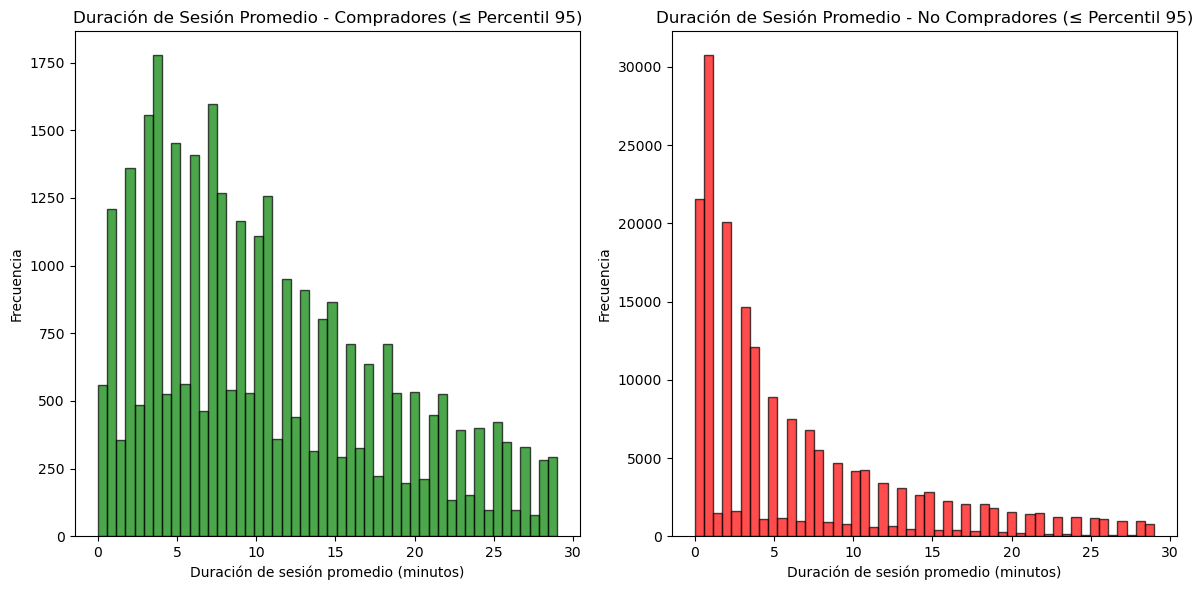

In [30]:
# se hace un histograma con la duración de sesión promedio de los usuarios que compraron y los que no compraron, sin el percentil 95 para mejor visualización
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.hist(buyers_without_outliers['avg_session_duration'], bins=50, color='green', edgecolor='black', alpha=0.7)
plt.title('Duración de Sesión Promedio - Compradores (≤ Percentil 95)')
plt.xlabel('Duración de sesión promedio (minutos)')
plt.ylabel('Frecuencia')
plt.subplot(1, 2, 2)
plt.hist(non_buyers_without_outliers['avg_session_duration'], bins=50, color='red', edgecolor='black', alpha=0.7)
plt.title('Duración de Sesión Promedio - No Compradores (≤ Percentil 95)')
plt.xlabel('Duración de sesión promedio (minutos)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

In [31]:
# Se comprueba la diferencia estadistica entre las distribuciones de compradores vs no compradores usando la prueba de Mann-Whitney U.
w_stat, w_p_value = mannwhitneyu(buyers_without_outliers['avg_session_duration'], non_buyers_without_outliers['avg_session_duration'], alternative='greater')

## Se imprimen los resultados de la prueba de Mann-Whitney U
print("=== Prueba de Mann-Whitney U: Compradores vs No Compradores (Duración de Sesión Promedio) ===")
print(f"Estadística U: {w_stat:.5f}")
print(f"Valor p: {w_p_value:.5f}")
print(f"Conclusión: {'Rechazamos la hipótesis nula' if w_p_value < 0.05 else 'No rechazamos la hipótesis nula'}")

=== Prueba de Mann-Whitney U: Compradores vs No Compradores (Duración de Sesión Promedio) ===
Estadística U: 4175836004.00000
Valor p: 0.00000
Conclusión: Rechazamos la hipótesis nula


### Investigación 4: Duración de sesión vs compra

Se analizó la relación entre la duración promedio de sesión (`avg_session_duration`) y la probabilidad de compra. Para evitar que los outliers (duraciones extremadamente largas) distorsionaran la visualización, ambos grupos se filtraron por el percentil 95 de la duración (≈38 minutos).

#### Análisis visual

- **Compradores:** La distribución es más suave y se extiende hasta los 30 minutos, con un pico en torno a los 4-7 minutos (~1,700 usuarios). La frecuencia decrece gradualmente a partir de los 7 minutos.
- **No compradores:** La distribución tiene un pico masivo en el minuto 1 (~31,000 usuarios) y cae en picado a partir del minuto 3. La mayoría de los no compradores abandona la plataforma en menos de 5 minutos.

#### Prueba estadística

Se aplicó la prueba de Mann-Whitney U (no paramétrica) para comparar las distribuciones de duración entre compradores y no compradores. La hipótesis alternativa planteaba que los compradores tienden a tener duraciones mayores (`alternative='greater'`).

- **Estadístico U:** 4.175e9
- **Valor p:** < 0.0001
- **Conclusión:** Se rechaza la hipótesis nula. La diferencia es estadísticamente significativa (p < 0.05).

#### Interpretación de negocio

Los usuarios que compran pasan, en promedio, más tiempo en la plataforma que los que no compran. Los no compradores son mayoritariamente "bounces" (entran y se van en menos de 3 minutos). Este hallazgo sugiere que **la duración de la sesión es un predictor de intención de compra**.

**Implicación:** Para el análisis de cohortes, la duración de sesión puede ser una variable de segmentación útil. Por ejemplo, se podrá evaluar si los usuarios que llegan en una cohorte temprana (C0) y tienen una duración larga presentan un LTV superior a los que llegan en la misma cohorte pero con duración corta.

#### Próximos pasos

Con las cuatro investigaciones del EDA cerradas (retención, pico de tráfico, intensivos de un solo día y duración vs compra), se procederá al análisis de cohortes y se integrarán los hallazgos de este bloque para enriquecer la segmentación de usuarios.

## Parte 4: construcción de cohortes

Una vez teniendo la información del EDA y el DataFrame del perfil de usuario, limpio e investigado. Se procede ha observar la distibución del tiempo de conversión de los compradores para establecer cohortes en relación a los datos.

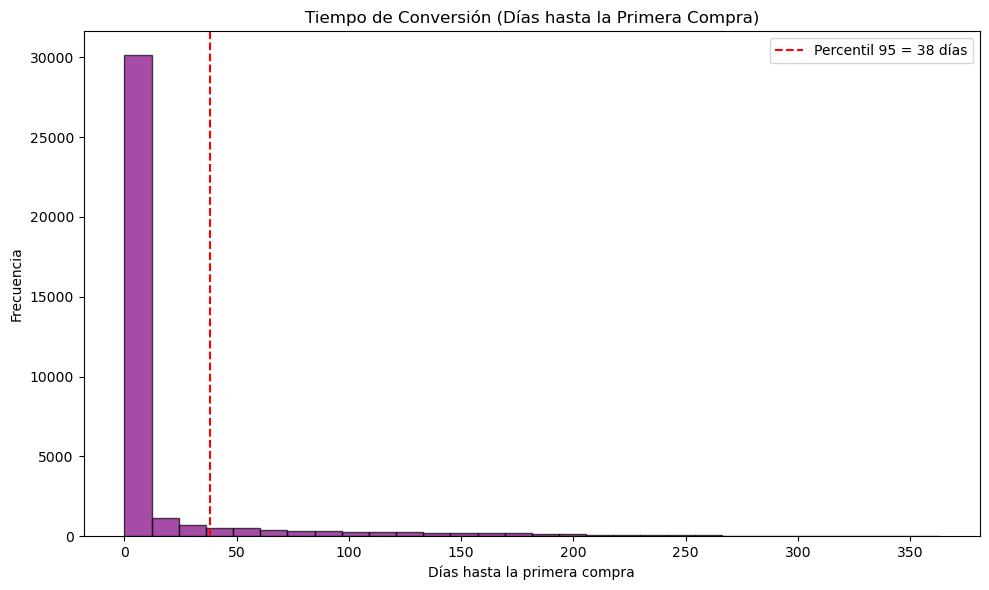

=== Estadísticas del Tiempo de Conversión (Días hasta la Primera Compra) ===
count    36523.000000
mean        16.729869
std         46.959088
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max        363.000000
Name: days_to_first_order, dtype: float64


In [32]:
# Se crea histograma del tiempo de conversión.
plt.figure(figsize=(10, 6))
plt.hist(user_profile[user_profile['buyer'] == True]['days_to_first_order'], bins=30, color='purple', edgecolor='black', alpha=0.7)
plt.title('Tiempo de Conversión (Días hasta la Primera Compra)')
plt.xlabel('Días hasta la primera compra')
plt.ylabel('Frecuencia')
plt.axvline(x=umbral, color='red', linestyle='--', label=f'Percentil 95 = {umbral:.0f} días')
plt.legend()
plt.tight_layout()
plt.show()
print('=== Estadísticas del Tiempo de Conversión (Días hasta la Primera Compra) ===')
print(user_profile[user_profile['buyer'] == True]['days_to_first_order'].describe())

### Definición de cohortes de conversión

A partir del histograma de `days_to_first_order`, se observa una distribución con un pico masivo en el día 0, una caída abrupta en los primeros 7 días, y una cola que se extiende hasta los 363 días. Para segmentar a los compradores de forma coherente con su comportamiento de compra, se utilizan los siguientes buckets:

- **C0:** conversión el mismo día (día 0).
- **C1:** conversión al día siguiente (día 1).
- **C2-7:** conversión entre 2 y 7 días.
- **C8-30:** conversión entre 8 y 30 días.
- **C30+:** conversión después de 30 días.

Estos cortes capturan la forma de la distribución: el pico en 0, la caída en la primera semana, el grupo de valor en el primer mes (C8-30), y la cola de compradores tardíos C30+ para no perder el volumen de usuarios que compran después de 30 días.

In [33]:
# Se crea una funcion que itera sobre 'days_to_first_order' que devuelve la cohorte al DF user_profile.
def assign_cohort(days):
    if days == 0:
        return 'c0'
    elif days == 1:
        return 'c1'
    elif 2 <= days <= 7:
        return 'c2-7'
    elif 8 <= days <= 30:
        return 'c8-30'
    elif days > 30:
        return 'c30+'
    else:
        return None

# se aplica la función al DataFrame user_profile para crear la columna 'cohort'
user_profile['cohort'] = user_profile['days_to_first_order'].apply(assign_cohort)

# Se imprime una muestra de 'user_profile' para verificar la nueva columna 'cohort'
print(user_profile[['uid', 'days_to_first_order', 'cohort']].sample(10))


                         uid  days_to_first_order cohort
45373    3670384548566424710                  NaN    NaN
18747    1520436657122691484                  NaN    NaN
119926   9697680273181309338                  NaN    NaN
79745    6424844696566750549                  NaN    NaN
215066  17376793268554294655                  NaN    NaN
17459    1416125106880685282                  NaN    NaN
141297  11411880522662100699                  NaN    NaN
120418   9738451973534775064                  NaN    NaN
219551  17750081160808354008                  NaN    NaN
59700    4830171824306141287                  NaN    NaN


cohort
NaN      191646
c0        26363
c30+       4902
c8-30      2178
c2-7       2069
c1         1011
Name: count, dtype: int64


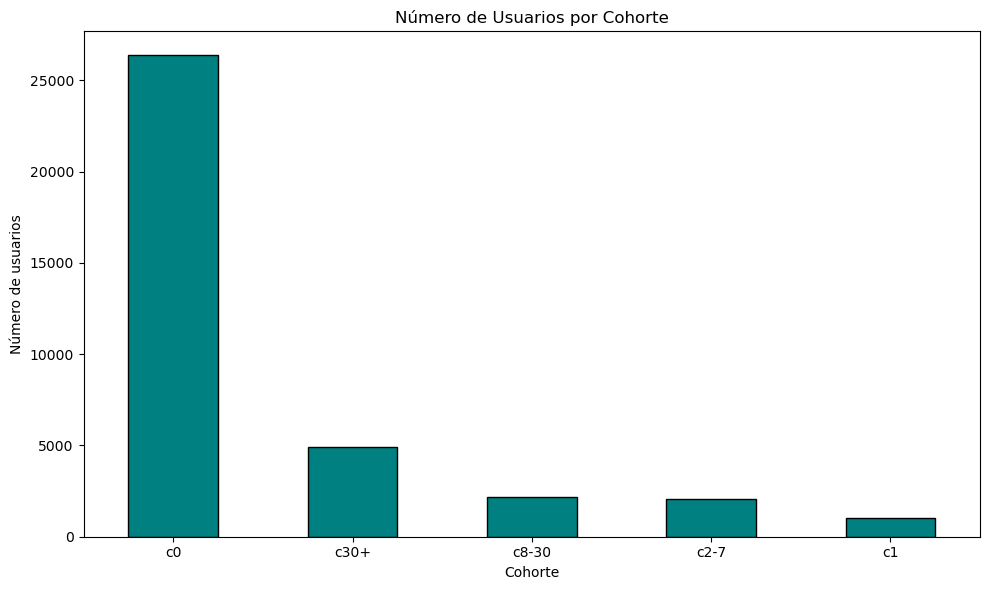

In [34]:
# Se crea un Series con el conteo de usuarios por cohorte, incluyendo los que no compraron (NaN).
cohorts_with_no_buyers = user_profile['cohort'].value_counts(dropna=False)
print(cohorts_with_no_buyers)

#gráfico de barras por cohorte (sólo compradores)
plt.figure(figsize=(10, 6))
user_profile['cohort'].value_counts(dropna=True).plot(kind='bar', color='teal', edgecolor='black')
plt.title('Número de Usuarios por Cohorte')
plt.xlabel('Cohorte')
plt.ylabel('Número de usuarios')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Ahora se crean los DataFrames para agrupar por cohorte y luego uno para analizar los costos de Marketing

In [35]:
# Se crea un DataFrame con las metricas agregadas por cohorte.
cohort_metrics = user_profile.groupby('cohort').agg(
    total_users=('uid', 'count'),
    total_orders=('total_orders', 'sum'),
    total_revenue=('total_revenue', 'sum'),
    average_session_duration=('avg_session_duration', 'mean')
).reset_index()

# se crean variables agregadas
cohort_metrics['average_ticket'] = cohort_metrics['total_revenue'] / cohort_metrics['total_orders']
cohort_metrics['orders_per_user'] = cohort_metrics['total_orders'] / cohort_metrics['total_users']
cohort_metrics['ltv_per_user'] = cohort_metrics['total_revenue'] / cohort_metrics['total_users']

# se imprime el dataframe con las métricas agregadas por cohorte
print(cohort_metrics.round(2))


  cohort  total_users  total_orders  total_revenue  average_session_duration  \
0     c0        26363       34237.0      156075.98                     15.89   
1     c1         1011        1812.0       10684.87                     13.69   
2   c2-7         2069        3451.0       16534.65                     12.87   
3   c30+         4902        7163.0       39431.16                     11.27   
4  c8-30         2178        3752.0       29330.54                     12.73   

   average_ticket  orders_per_user  ltv_per_user  
0            4.56             1.30          5.92  
1            5.90             1.79         10.57  
2            4.79             1.67          7.99  
3            5.50             1.46          8.04  
4            7.82             1.72         13.47  


### Análisis de cohortes de conversión

Se segmentó a los usuarios compradores según el tiempo transcurrido entre su primera visita y su primera compra. Los buckets utilizados (C0, C1, C2-7, C8-30, C30+) se definieron a partir de la distribución observada, que muestra una caída abrupta después del día 0 y una cola que se extiende hasta los 363 días.

**Distribución de compradores:**
- C0 (mismo día): 72.2% (26,363 usuarios)
- C1 (1 día): 2.8% (1,011 usuarios)
- C2-7 (2 a 7 días): 5.7% (2,069 usuarios)
- C8-30 (8 a 30 días): 6.0% (2,178 usuarios)
- C30+ (más de 30 días): 13.4% (4,902 usuarios)

**Métricas económicas por cohorte:**

| Cohorte | Usuarios | LTV (por usuario) | Ticket Promedio | Pedidos / Usuario |
| :--- | :--- | :--- | :--- | :--- |
| **c0** | 26,363 | $5.92 | $4.56 | 1.30 |
| **c1** | 1,011 | $10.57 | $5.90 | 1.79 |
| **c2-7** | 2,069 | $7.99 | $4.79 | 1.67 |
| **c8-30** | 2,178 | $13.47 | $7.82 | 1.72 |
| **c30+** | 4,902 | $8.04 | $5.50 | 1.46 |

**Hallazgos clave:**

- **C8-30 (de 8 a 30 días):** Es la cohorte más valiosa en términos de LTV ($13.47) y ticket promedio ($7.82). Aunque es pequeña (6%), representa un segmento de alta intención que merece esfuerzos de retargeting.
- **C0 (compra inmediata):** Es la cohorte dominante en volumen (72%) pero con el LTV más bajo ($5.92). La estrategia para este grupo debe enfocarse en upselling inmediato para aumentar el ticket.
- **C30+ (compra tardía):** Es la segunda cohorte más grande (13.4%), con un LTV intermedio ($8.04). Estos usuarios probablemente requieren campañas de recordatorio a largo plazo.

**Implicación para marketing:** La estrategia debe diferenciarse por cohorte. No es lo mismo retener a un comprador impulsivo (C0) que a uno reflexivo (C8-30). Las campañas de retargeting deberían priorizar a los usuarios que se acercan a la ventana de 8-30 días.

**Siguientes pasos:** Se hará el análisis de los costos de Marketing para tener una mirada completa de los datos y generar estrategias accionables.

In [36]:
# se crea un DF para el análisis de los costos de adquisición por fuente de tráfico
acquisition_costs = user_profile.groupby('first_touch_source').agg(
    total_users=('uid', 'nunique'),
    total_revenue=('total_revenue', lambda x: x.fillna(0).sum())
).reset_index()

# se agrupa costs_log por source_id
costs_by_source = costs_log.groupby('source_id').agg(
    total_cost=('costs', 'sum')).reset_index()

# se hace el merge de acquisition_costs y costs_by_source
acquisition_costs = pd.merge(acquisition_costs, costs_by_source, left_on='first_touch_source', right_on='source_id', how='left')

print(acquisition_costs)


   first_touch_source  total_users  total_revenue  source_id  total_cost
0                   1         9469       31090.55        1.0    20833.27
1                   2        17616       46923.61        2.0    42806.04
2                   3        66116       54511.24        3.0   141321.63
3                   4        72346       56696.83        4.0    61073.60
4                   5        49237       52624.02        5.0    51757.10
5                   6            2           0.00        NaN         NaN
6                   7           32           1.22        NaN         NaN
7                   9         6448        5759.40        9.0     5517.49
8                  10         6903        4450.33       10.0     5822.49


In [37]:
# Eliminar fuentes sin costos (6 y 7) y la columna duplicada source_id
acquisition_costs_clean = acquisition_costs.dropna(subset=['total_cost']).drop(columns=['source_id'])
# se renombra first_touch_source a marketing_source_id para mayor claridad
acquisition_costs_clean = acquisition_costs_clean.rename(columns={'first_touch_source': 'marketing_source_id'})
# Ver el resultado
print(acquisition_costs_clean)

   marketing_source_id  total_users  total_revenue  total_cost
0                    1         9469       31090.55    20833.27
1                    2        17616       46923.61    42806.04
2                    3        66116       54511.24   141321.63
3                    4        72346       56696.83    61073.60
4                    5        49237       52624.02    51757.10
7                    9         6448        5759.40     5517.49
8                   10         6903        4450.33     5822.49


In [38]:
# se agrega el ROMI y el CAC al DataFrame acquisition_costs_clean
# Calcular CAC y ROMI
acquisition_costs_clean['CAC'] = acquisition_costs_clean['total_cost'] / acquisition_costs_clean['total_users']
acquisition_costs_clean['ROMI'] = ((acquisition_costs_clean['total_revenue'] - acquisition_costs_clean['total_cost']) / acquisition_costs_clean['total_cost']) * 100

# Mostrar con 2 decimales
print(acquisition_costs_clean.round(2))

   marketing_source_id  total_users  total_revenue  total_cost   CAC   ROMI
0                    1         9469       31090.55    20833.27  2.20  49.24
1                    2        17616       46923.61    42806.04  2.43   9.62
2                    3        66116       54511.24   141321.63  2.14 -61.43
3                    4        72346       56696.83    61073.60  0.84  -7.17
4                    5        49237       52624.02    51757.10  1.05   1.67
7                    9         6448        5759.40     5517.49  0.86   4.38
8                   10         6903        4450.33     5822.49  0.84 -23.57


### Análisis de eficiencia de marketing (CAC y ROMI)

Se evaluó el rendimiento de cada canal de adquisición (`first_touch_source`) combinando los datos de usuarios (`user_profile`) y los costos de marketing (`costs_log`). El ingreso total se calculó incluyendo a todos los usuarios (con `0` para los no compradores), reflejando el retorno real de cada fuente.

**Métricas clave:**

| Canal | Usuarios | Ingreso total | Costo total | CAC | ROMI |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Source 1 | 9,469 | $31,090.55 | $20,833.27 | $2.20 | 49.24% |
| Source 2 | 17,616 | $46,923.61 | $42,806.04 | $2.43 | 9.62% |
| Source 3 | 66,116 | $54,511.24 | $141,321.63 | $2.14 | -61.43% |
| Source 4 | 72,346 | $56,696.83 | $61,073.60 | $0.84 | -7.17% |
| Source 5 | 49,237 | $52,624.02 | $51,757.10 | $1.05 | 1.67% |
| Source 9 | 6,448 | $5,759.40 | $5,517.49 | $0.86 | 4.38% |
| Source 10 | 6,903 | $4,450.33 | $5,822.49 | $0.84 | -23.57% |

**Hallazgos clave:**

- **Source 3** es el canal de mayor inversión ($141,321) pero el único con pérdidas significativas (ROMI -61%). A pesar de atraer a 66,116 usuarios, su ingreso generado ($54,511) no cubre ni la mitad del gasto. 

- **Source 1** es el canal más rentable (ROMI 49%). Aunque tiene el CAC más alto ($2.20), genera un retorno positivo sólido. 

- **Source 2** tiene un ROMI moderado (9.6%) y un CAC de $2.43. Es un canal estable que puede mantenerse o escalarse ligeramente.

- **Source 4 y 10** tienen el CAC más bajo ($0.84), pero ambos tienen ROMI negativo (-7.17% y -23.57%). Su bajo costo de adquisición no compensa el bajo ingreso que generan. 

- **Source 5 y 9** están cerca del equilibrio (ROMI 1.6% y 4.3%). Son canales marginales que no generan pérdidas significativas pero tampoco crecimiento.

**Próximos pasos:**  
Para poder recomendar acciones concretas es necesario entender _por qué_ estos canales tienen un rendimiento tan distinto. Para ello, se cruzará la información de comportamiento (cohorte, retención y duración) con cada fuente de tráfico. Esto permitirá responder preguntas como:

1. **Calidad de la conversión:** ¿Source 3 atrae a más compradores de bajo valor (C0) que otros canales, o su mala performance se debe puramente al costo?
2. **Retención:** ¿Los usuarios de Source 1 regresan más días que los de Source 3? Una mayor retención justifica un CAC más alto.
3. **Engagement:** ¿Los usuarios de Source 1 pasan más tiempo en la plataforma que los de Source 3? La duración de sesión es un predictor de intención de compra.

In [39]:
# se crea tabla dinamica para responder el primer punto
quality_convertion_table = pd.crosstab(
    index=user_profile['first_touch_source'],
    columns=user_profile['cohort'].fillna('no buyer'),
    normalize='index' # esto vuelve los valores en proporciones, útil para ver la distribución de cohortes por fuente de tráfico
)
print(quality_convertion_table.round(2))

cohort                c0    c1  c2-7  c30+  c8-30  no buyer
first_touch_source                                         
1                   0.24  0.01  0.02  0.02   0.02      0.69
2                   0.14  0.01  0.01  0.03   0.01      0.80
3                   0.11  0.00  0.01  0.02   0.01      0.84
4                   0.10  0.00  0.01  0.02   0.01      0.86
5                   0.11  0.00  0.01  0.02   0.01      0.86
6                   0.00  0.00  0.00  0.00   0.00      1.00
7                   0.03  0.00  0.00  0.00   0.00      0.97
9                   0.08  0.00  0.01  0.06   0.02      0.83
10                  0.15  0.01  0.01  0.02   0.01      0.81


In [40]:
# Se revisa la retención por fuente
retention_by_source = user_profile.groupby('first_touch_source')['total_days_active'].mean().reset_index()
print("=== Retención por Fuente de Tráfico ===")
print(retention_by_source.round(2))
print()

# se revisa la duración de sesión promedio por fuente de tráfico
duration_by_source = user_profile.groupby('first_touch_source')['avg_session_duration'].mean().reset_index()
print("=== Duración de Sesión Promedio por Fuente de Tráfico ===")
print(duration_by_source.round(2))

=== Retención por Fuente de Tráfico ===
  first_touch_source  total_days_active
0                  1               2.08
1                  2               2.01
2                  3               1.41
3                  4               1.35
4                  5               1.29
5                  6               1.50
6                  7               1.09
7                  9               1.82
8                 10               1.38

=== Duración de Sesión Promedio por Fuente de Tráfico ===
  first_touch_source  avg_session_duration
0                  1                 12.18
1                  2                 10.15
2                  3                  8.89
3                  4                  8.60
4                  5                  7.81
5                  6                  7.67
6                  7                 10.44
7                  9                  8.74
8                 10                  8.60


In [41]:
# ahora se unen las tablas y series para armar un DataFrame final con todas las métricas de marketing
# se reinicia index de quality_convertion_table para poder hacer merge
quality_convertion_table_reset = quality_convertion_table.reset_index()

# se renombran columnas para que sean claras pct 
quality_convertion_table_reset.columns = [
    'marketing_source_id',
    'pct_c0',          # primero aparece c0
    'pct_c1',          # luego c1
    'pct_c2-7',        # luego c2-7
    'pct_c30+',        # luego c30+
    'pct_c8-30',       # luego c8-30
    'pct_no_buyer'     # último: no buyer
]

# se une todo en un solo DataFrame para análisis de marketing
full_marketing_analysis = acquisition_costs_clean.merge(
    retention_by_source,
    left_on='marketing_source_id',
    right_on='first_touch_source',
    how='left'
).merge(
    duration_by_source,
    on='first_touch_source',
    how='left'
).merge(
    quality_convertion_table_reset,
    on='marketing_source_id',
    how='left'
).drop(columns=['first_touch_source'])  # limpiar columnas duplicadas

print("=== Análisis Completo de Marketing ===")
print(full_marketing_analysis.round(2))

=== Análisis Completo de Marketing ===
  marketing_source_id  total_users  total_revenue  total_cost   CAC   ROMI  \
0                   1         9469       31090.55    20833.27  2.20  49.24   
1                   2        17616       46923.61    42806.04  2.43   9.62   
2                   3        66116       54511.24   141321.63  2.14 -61.43   
3                   4        72346       56696.83    61073.60  0.84  -7.17   
4                   5        49237       52624.02    51757.10  1.05   1.67   
5                   9         6448        5759.40     5517.49  0.86   4.38   
6                  10         6903        4450.33     5822.49  0.84 -23.57   

   total_days_active  avg_session_duration  pct_c0  pct_c1  pct_c2-7  \
0               2.08                 12.18    0.24    0.01      0.02   
1               2.01                 10.15    0.14    0.01      0.01   
2               1.41                  8.89    0.11    0.00      0.01   
3               1.35                  8.60    0.

### Análisis integrado de marketing y calidad de tráfico

Se ha consolidado la información de eficiencia financiera (CAC/ROMI) con las métricas de comportamiento (retención, duración y calidad de conversión) para cada fuente de tráfico. La tabla completa se muestra a continuación:

| Source | Usuarios | CAC | ROMI | Días activos (media) | Duración (media) | % No compradores | % C0 | % C8-30 | % C30+ |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 1 | 9,469 | $2.20 | 49% | 2.08 | 12.18 min | 69% | 24% | 2% | 2% |
| 2 | 17,616 | $2.43 | 10% | 2.01 | 10.15 min | 80% | 14% | 1% | 3% |
| 3 | 66,116 | $2.14 | -61% | 1.41 | 8.89 min | 84% | 11% | 1% | 2% |
| 4 | 72,346 | $0.84 | -7% | 1.35 | 8.60 min | 86% | 10% | 1% | 2% |
| 5 | 49,237 | $1.05 | 2% | 1.29 | 7.81 min | 86% | 11% | 1% | 2% |
| 9 | 6,448 | $0.86 | 4% | 1.82 | 8.74 min | 83% | 8% | 2% | 6% |
| 10 | 6,903 | $0.84 | -24% | 1.38 | 8.60 min | 81% | 15% | 1% | 2% |

#### Hallazgos clave

1. **Source 1** es el canal más eficiente en todos los aspectos: tiene el mejor ROMI (49%), la mayor retención (2.08 días) y la mayor duración (12.18 min). Además, presenta la menor proporción de no compradores (69%) y la mayor proporción de compradores inmediatos (C0: 24%). 

2. **Source 3** es el canal más ineficiente: ROMI -61%, baja retención (1.41 días) y baja duración (8.89 min). Atrae un 84% de no compradores y prácticamente ningún comprador de alto valor (C8-30: 1%). 

3. **Source 4 y 10** son económicos (CAC ~$0.84) pero ineficientes (ROMI negativo), con alta proporción de no compradores (>81%) y baja retención. 

4. **Source 9** presenta un caso particular: aunque su ROMI es bajo (4%), destaca por tener la mayor proporción de compradores tardíos (C30+: 6%) y una retención relativamente alta (1.82 días). Esto sugiere que atrae a usuarios que investigan y compran después de un tiempo prolongado. 

In [42]:
# se exportan csv de los datos relevantes para la produccion de Dashboards y reportes
# Exportar el análisis completo de marketing
full_marketing_analysis.to_csv('datasets/processed/marketing_analysis_powerbi.csv', index=False)

cohort_metrics.to_csv('datasets/processed/cohort_metrics_powerbi.csv', index=False)

# se rellenan los NaN con 0 y no_buyer para mejor manejo 
user_profile_pbi = user_profile.copy()
user_profile_pbi['cohort'] = user_profile_pbi['cohort'].fillna('no_buyer')
user_profile_pbi['total_revenue'] = user_profile_pbi['total_revenue'].fillna(0)
user_profile_pbi['total_orders'] = user_profile_pbi['total_orders'].fillna(0)
user_profile_pbi.to_csv('datasets/processed/user_profile_powerbi.csv', index=False)

# Conclusiones finales y recomendaciones estratégicas

El análisis integral de la plataforma Showz ha permitido conectar el comportamiento de los usuarios con la eficiencia de los canales de marketing. A continuación, se resumen los hallazgos principales y se presentan las recomendaciones accionables, ordenadas por urgencia.

### 1. Resumen de hallazgos de comportamiento

- **Retención crítica:** El 80% de los usuarios no regresa después de su primer día de actividad. La plataforma depende casi exclusivamente de la adquisición constante de nuevos usuarios. La mediana de días activos es 1, y el percentil 75 es 3.
- **Estacionalidad y eventos:** El tráfico es estacional con un pico en noviembre (Black Friday) y un valle en agosto. El pico de Black Friday fue impulsado principalmente por usuarios recurrentes (44.86% de compra vs 33.77% anual), no por nuevos. Esto indica que las campañas de noviembre son efectivas para *reactivar*, no solo para adquirir.
- **Intensivos de un solo día:** Los usuarios que tienen múltiples sesiones en un mismo día (pero no regresan al día siguiente) compran al 40.60%, frente al 10.47% de los que solo tienen una sesión (Z=77.53, p=0). Este comportamiento es una señal inequívoca de alta intención de compra.
- **Duración de sesión:** Los compradores pasan significativamente más tiempo en la plataforma que los no compradores (Mann-Whitney U, p<0.0001). Los no compradores son mayoritariamente "bounces" (abandonan en menos de 3 minutos).
- **Cohortes de conversión más importantes:**
    - **C0 (compra inmediata):** 72.2% de los compradores. LTV más bajo ($5.92). Estrategia: upselling para aumentar el ticket.
    - **C8-30 (8 a 30 días):** Solo el 6% de los compradores, pero es la cohorte más valiosa (LTV $13.47, ticket $7.82). Estrategia: retargeting y campañas de recordatorio.
    - **C30+ (más de 30 días):** 13.4% de los compradores. LTV intermedio ($8.04). Estrategia: campañas de largo plazo y seguimiento de usuarios que no compran en el corto plazo.

### 2. Recomendaciones por canal de marketing (ordenadas por urgencia)

#### Prioridad 1: Eliminar o reducir drásticamente (canales con pérdida confirmada)

- **Source 10:** Bajo volumen (6,903 usuarios) y pérdida significativa (ROMI -24%). No tiene potencial de escala. **Recomendación:** Eliminar la inversión y redirigir el presupuesto a Source 1 (donde el retorno está probado).

- **Source 3:** Es el canal de mayor inversión ($141,321) y el único con pérdidas masivas (ROMI -61%). Atrae a 66,116 usuarios, pero el 84% no compra, su retención es baja (1.41 días) y prácticamente no genera compradores de alto valor (C8-30 = 1%). Esto indica un **desajuste estructural entre el mensaje publicitario y la propuesta de valor real de la plataforma**.
    - **Análisis de contexto (Black Friday):** Si bien Source 3 impulsó el pico de noviembre, los usuarios que trajo fueron mayoritariamente de baja calidad (C0 y no compradores), lo que explica su pésimo ROMI anual.
    - **Recomendación:** Reducir la inversión en un **80%** y redirigir esos fondos a Source 1. El **20% restante** se destinará a probar un mensaje más alineado con el público objetivo (targeting específico). Se establece un **umbral de éxito de 1.6 días activos** para evaluar esta prueba. Este número es la media entre la retención de los canales de bajo rendimiento (Source 4 y 5: ~1.3 días) y los de rendimiento aceptable (Source 9: 1.82 días).
        - Si la retención de Source 3 supera 1.6 días, significa que el nuevo targeting está atrayendo a usuarios que vuelven, y se reconsiderará su inversión.
        - Si no se alcanza este umbral en un mes, eliminar la inversión.
    - **Variante estacional:** Dado el comportamiento observado en Black Friday, se sugiere que, en lugar de mantenerla activa todo el año, la inversión en Source 3 (si se mantiene) se **concentre exclusivamente en periodos de alta demanda estacional** (ej. Black Friday, Cyber Monday), donde el volumen masivo puede ser útil a pesar de la baja calidad, siempre que se mida contra el umbral de retención.

#### Prioridad 2: Optimizar e investigar (canales con potencial de mejora)

- **Source 4:** Es el canal con mayor escala (72,346 usuarios) y el CAC más bajo ($0.84). Su pérdida es marginal (ROMI -7%). Su tasa de C0 es baja (10%), lo que lastra su rentabilidad.
    - **Recomendación:** Mantener el presupuesto, pero **optimizar la landing page específica para este tráfico** (mensaje directo, llamado a la acción claro). Si se logra aumentar la tasa de C0 del 10% al 12% (un incremento de solo 2 puntos porcentuales), el ROMI se volvería positivo (estimado ~+5%). Esta intervención es de bajo costo y alto potencial de retorno dada su escala.

- **Source 5:** Está en equilibrio financiero (ROMI 1.6%), pero tiene la **peor retención (1.29 días)** y la **peor duración (7.81 min)** de todos los canales.
    - **Recomendación:** No tomar decisiones inmediatas. Se recomienda **investigar la distribución horaria y el dispositivo** de este tráfico. Si la mayoría de las sesiones ocurren en horario nocturno o provienen de móvil, podría tratarse de tráfico de baja intención (búsquedas casuales). Si se confirma, reducir el presupuesto en un 50% y reasignarlo. Si el tráfico es similar al de otros canales, mantenerlo como canal de respaldo.

#### Prioridad 3: Potenciar y mantener (canales rentables o estratégicos)

- **Source 1:** Es el canal más rentable en todos los aspectos: ROMI 49%, mayor retención (2.08 días), mayor duración (12.18 min), menor proporción de no compradores (69%) y mayor proporción de compradores inmediatos (C0: 24%).
    - **Recomendación:** Aumentar la inversión en este canal. La estrategia debe enfocarse en **maximizar el ticket promedio en el momento de la compra**, implementando **upselling y cross-selling** durante la sesión (ej. "agregar seguro al evento", "paquete VIP"), dado que estos usuarios ya llegan con alta intención.

- **Source 2:** Tiene alta retención (2.01 días) y duración (10.15 min), pero su conversión inmediata (C0) es baja (14%). El perfil de estos usuarios encaja con la cohorte de **mayor valor (C8-30, LTV $13.47)**.
    - **Recomendación:** Mantener o aumentar ligeramente la inversión. La estrategia debe ser de **nurturing**: implementar campañas de email marketing a los 5 y 15 días para mantener el interés y empujar la compra hacia la ventana de 8-30 días, en lugar de dejarlos madurar a C30+ (menos valioso).

- **Source 9:** Es el único canal con una proporción destacable de compradores tardíos (C30+: 6% frente al ~2% de los demás). Su ROMI es positivo (4%) y su retención es aceptable (1.82 días).
    - **Recomendación:** Mantener la inversión actual (sin aumentos). Es un canal de **"vigilancia"**. Se sugiere **monitorear el comportamiento de los usuarios de Source 9** para evaluar si su LTV crece con el tiempo. Hasta entonces, mantener presupuesto mínimo.

### 3. Recomendaciones transversales (Producto y Marketing)

- **Retargeting por cohorte:** Priorizar campañas de retargeting para usuarios que se acercan a la ventana de **8-30 días**, ya que son los de mayor valor (LTV $13.47). Las campañas de recordatorio deben dirigirse a este grupo, mientras que para el grupo C0 el foco debe ser el upselling inmediato.
- **Monitoreo y periodicidad:** Implementar el sistema de ranking y análisis de cohortes de forma **mensual** para evaluar el impacto de las recomendaciones y ajustar el presupuesto en tiempo real.